# ✈️ NASA C-MAPSS FD001 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

** **ML·DL 통합 분기 / DL Long Format CSV 저장 / random_state=42 엔진 분할**

공통: 상수 센서 제거 → RUL cap=125 → Gaussian → Validation 분할 → 정규화  
ML 분기: lag·diff·rolling·std·EMA  |  DL 분기: 슬라이딩 윈도우

이번 버전은 **가우시안 스무딩 → 엔진 단위 랜덤 validation 분리(random_state=42) → sub-train 기준 정규화 → ML/DL 분기 처리** 흐름으로 구성했습니다.


이번 최종본은 **rolling std / EMA까지 포함한 시계열 파생변수**, **엔진 단위 랜덤 validation 분리(random_state=42)**, **sub-train 기준 정규화**를 반영한 버전이다.


## 0. 환경 설정

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

TEMPORAL_LAGS  = [1, 3, 5]
TEMPORAL_DIFFS = [1]
TEMPORAL_ROLLS = [3, 5]

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS = [5]


✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01


## 1. 데이터 로딩 & 컬럼명 표준화

In [2]:
DATA_DIR = '../YJ'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [3]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,20631,0,0,0,100,✅ 정상
Test,13096,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,0.0016
s_8,2388.0967,0.0710,2387.9000,2388.5600,0.0000
s_9,9065.2429,22.0829,9021.7300,9244.5900,0.0024
s_10,1.3000,0.0000,1.3000,1.3000,0.0000



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상


### 📊 2-1. 기초 통계 & 데이터 품질 검사 결과

---

#### 데이터 품질 확인
| 항목 | Train | Test |
|------|-------|------|
| 전체 행 | 20,631 | 13,096 |
| 결측치 | 0 | 0 |
| 중복 행 | 0 | 0 |
| 음수 센서 | 0 | 0 |
| 엔진 수 | 100 | 100 |

> ✅ 결측치, 중복, 음수 전부 없음  
> → C-MAPSS는 컴퓨터 시뮬레이션 데이터라 매우 깨끗함  
> → 별도 결측치 처리 불필요

---

#### CV(변동계수) 해석
> CV = std / mean → 값이 클수록 센서가 많이 변함  
> CV ≈ 0 → 비행 내내 거의 같은 값 → 열화 정보 없음 → 제거 대상

**상수 센서 (CV ≈ 0, 제거 대상)**
| 센서 | CV | 판정 |
|------|----|------|
| s_1 | 0.0000 | 완전 상수 |
| s_5 | 0.0000 | 완전 상수 |
| s_6 | 0.0001 | 사실상 상수 |
| s_10 | 0.0000 | 완전 상수 |
| s_16 | 0.0000 | 완전 상수 |
| s_18 | 0.0000 | 완전 상수 |
| s_19 | 0.0000 | 완전 상수 |

**유용 센서 (CV > 0, 유지 대상)**
| 센서 | CV | 특징 |
|------|----|------|
| s_4 | 0.0064 | 가장 변동 큼 → 열화 신호 강함 |
| s_20 | 0.0047 | 변동 큼 |
| s_21 | 0.0046 | 변동 큼 |
| s_15 | 0.0044 | 변동 큼 |
| s_11 | 0.0056 | 변동 큼 |

> 💡 CV가 크다고 무조건 좋은 센서는 아님  
> → 이후 RUL 상관계수 분석에서 실제 열화와 연관된 센서 확인 예정

---

#### 🔑 핵심 결론
> **데이터 품질 이상 없음**  
> **s_1, s_5, s_6, s_10, s_16, s_18, s_19 → 상수 센서 → 제거 대상**  
> **나머지 14개 센서 → 열화 정보 포함 가능 → 유지**

### 2-2. 엔진 수명 분포

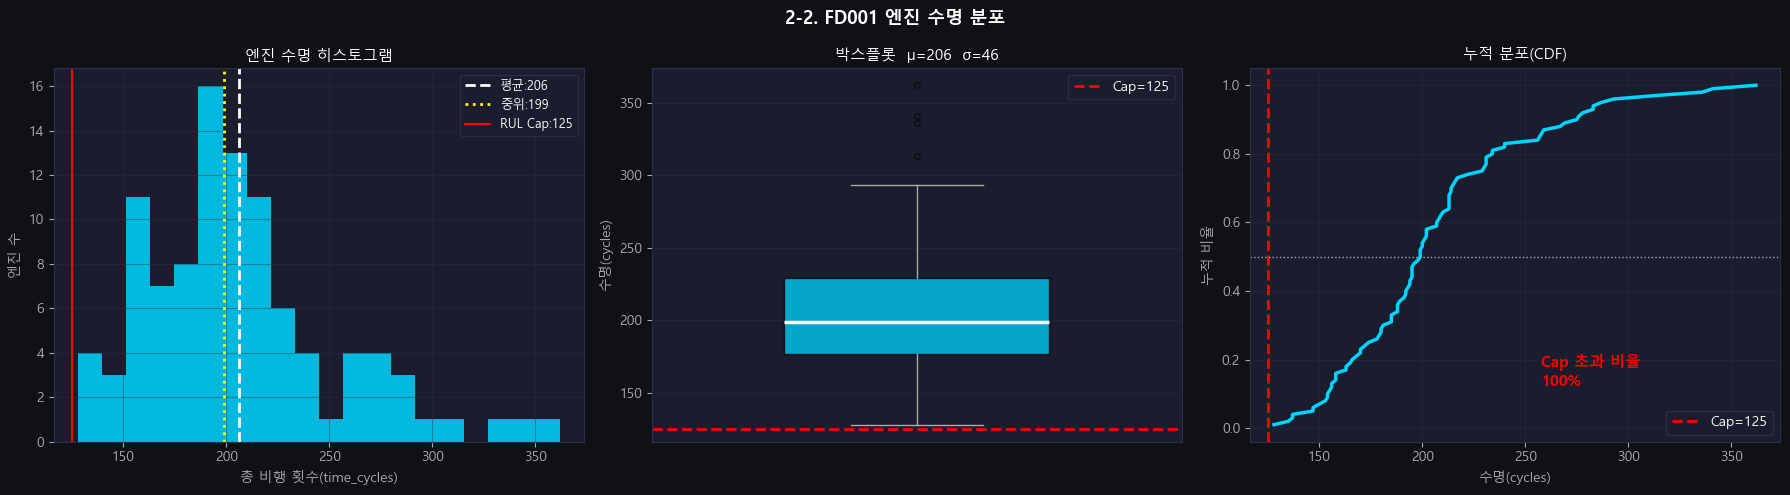


엔진 수명 통계:
  평균=206.3  중위=199.0  min=128  max=362
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [4]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD001 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 📊 2-2. 엔진 수명 분포 분석 결과

---

#### 히스토그램 해석
- x축: 총 비행 횟수 (엔진 수명)
- y축: 해당 수명을 가진 엔진 수
- **150~250 구간에 엔진이 가장 많이 분포**
- 평균 206번, 중위수 199번으로 비슷 → 분포가 크게 치우치지 않음
- 빨간 수직선(Cap=125): 모든 엔진이 이 선 오른쪽에 위치
  → **어떤 엔진도 125사이클 이전에 고장나지 않음**

---

#### 박스플롯 해석
- 박스(25~75%): 대부분 엔진이 175~250 사이클 수명
- 흰 가로선(중위수): 199사이클
- 수염 끝(최솟값~최댓값): 128~362
- 빨간 점선(Cap=125): 박스 전체가 Cap 위에 있음
  → **Cap=125가 어떤 엔진의 정상 구간도 침범하지 않음을 증명**

---

#### CDF(누적 분포) 해석
- x축: 수명, y축: 누적 비율(0~1)
- 곡선이 빨간 점선(Cap=125)을 만나는 y값 = 0
  → **Cap=125 이하 엔진이 0% = 100% 엔진이 Cap 초과**
- 곡선이 0.5를 만나는 x값 ≈ 199 → 중위수 확인

---

#### 🔑 핵심 결론
> **모든 엔진(100%)의 수명이 125사이클을 초과**  
> → 125사이클 이하 구간은 열화와 무관한 정상 운전 구간  
> → 이 구간의 RUL을 전부 125로 고정해도 실제 정보 손실 없음  
> → **Cap=125 설정의 데이터 기반 근거**

### 2-3. 센서 분포 & 이상치 (전처리 전)

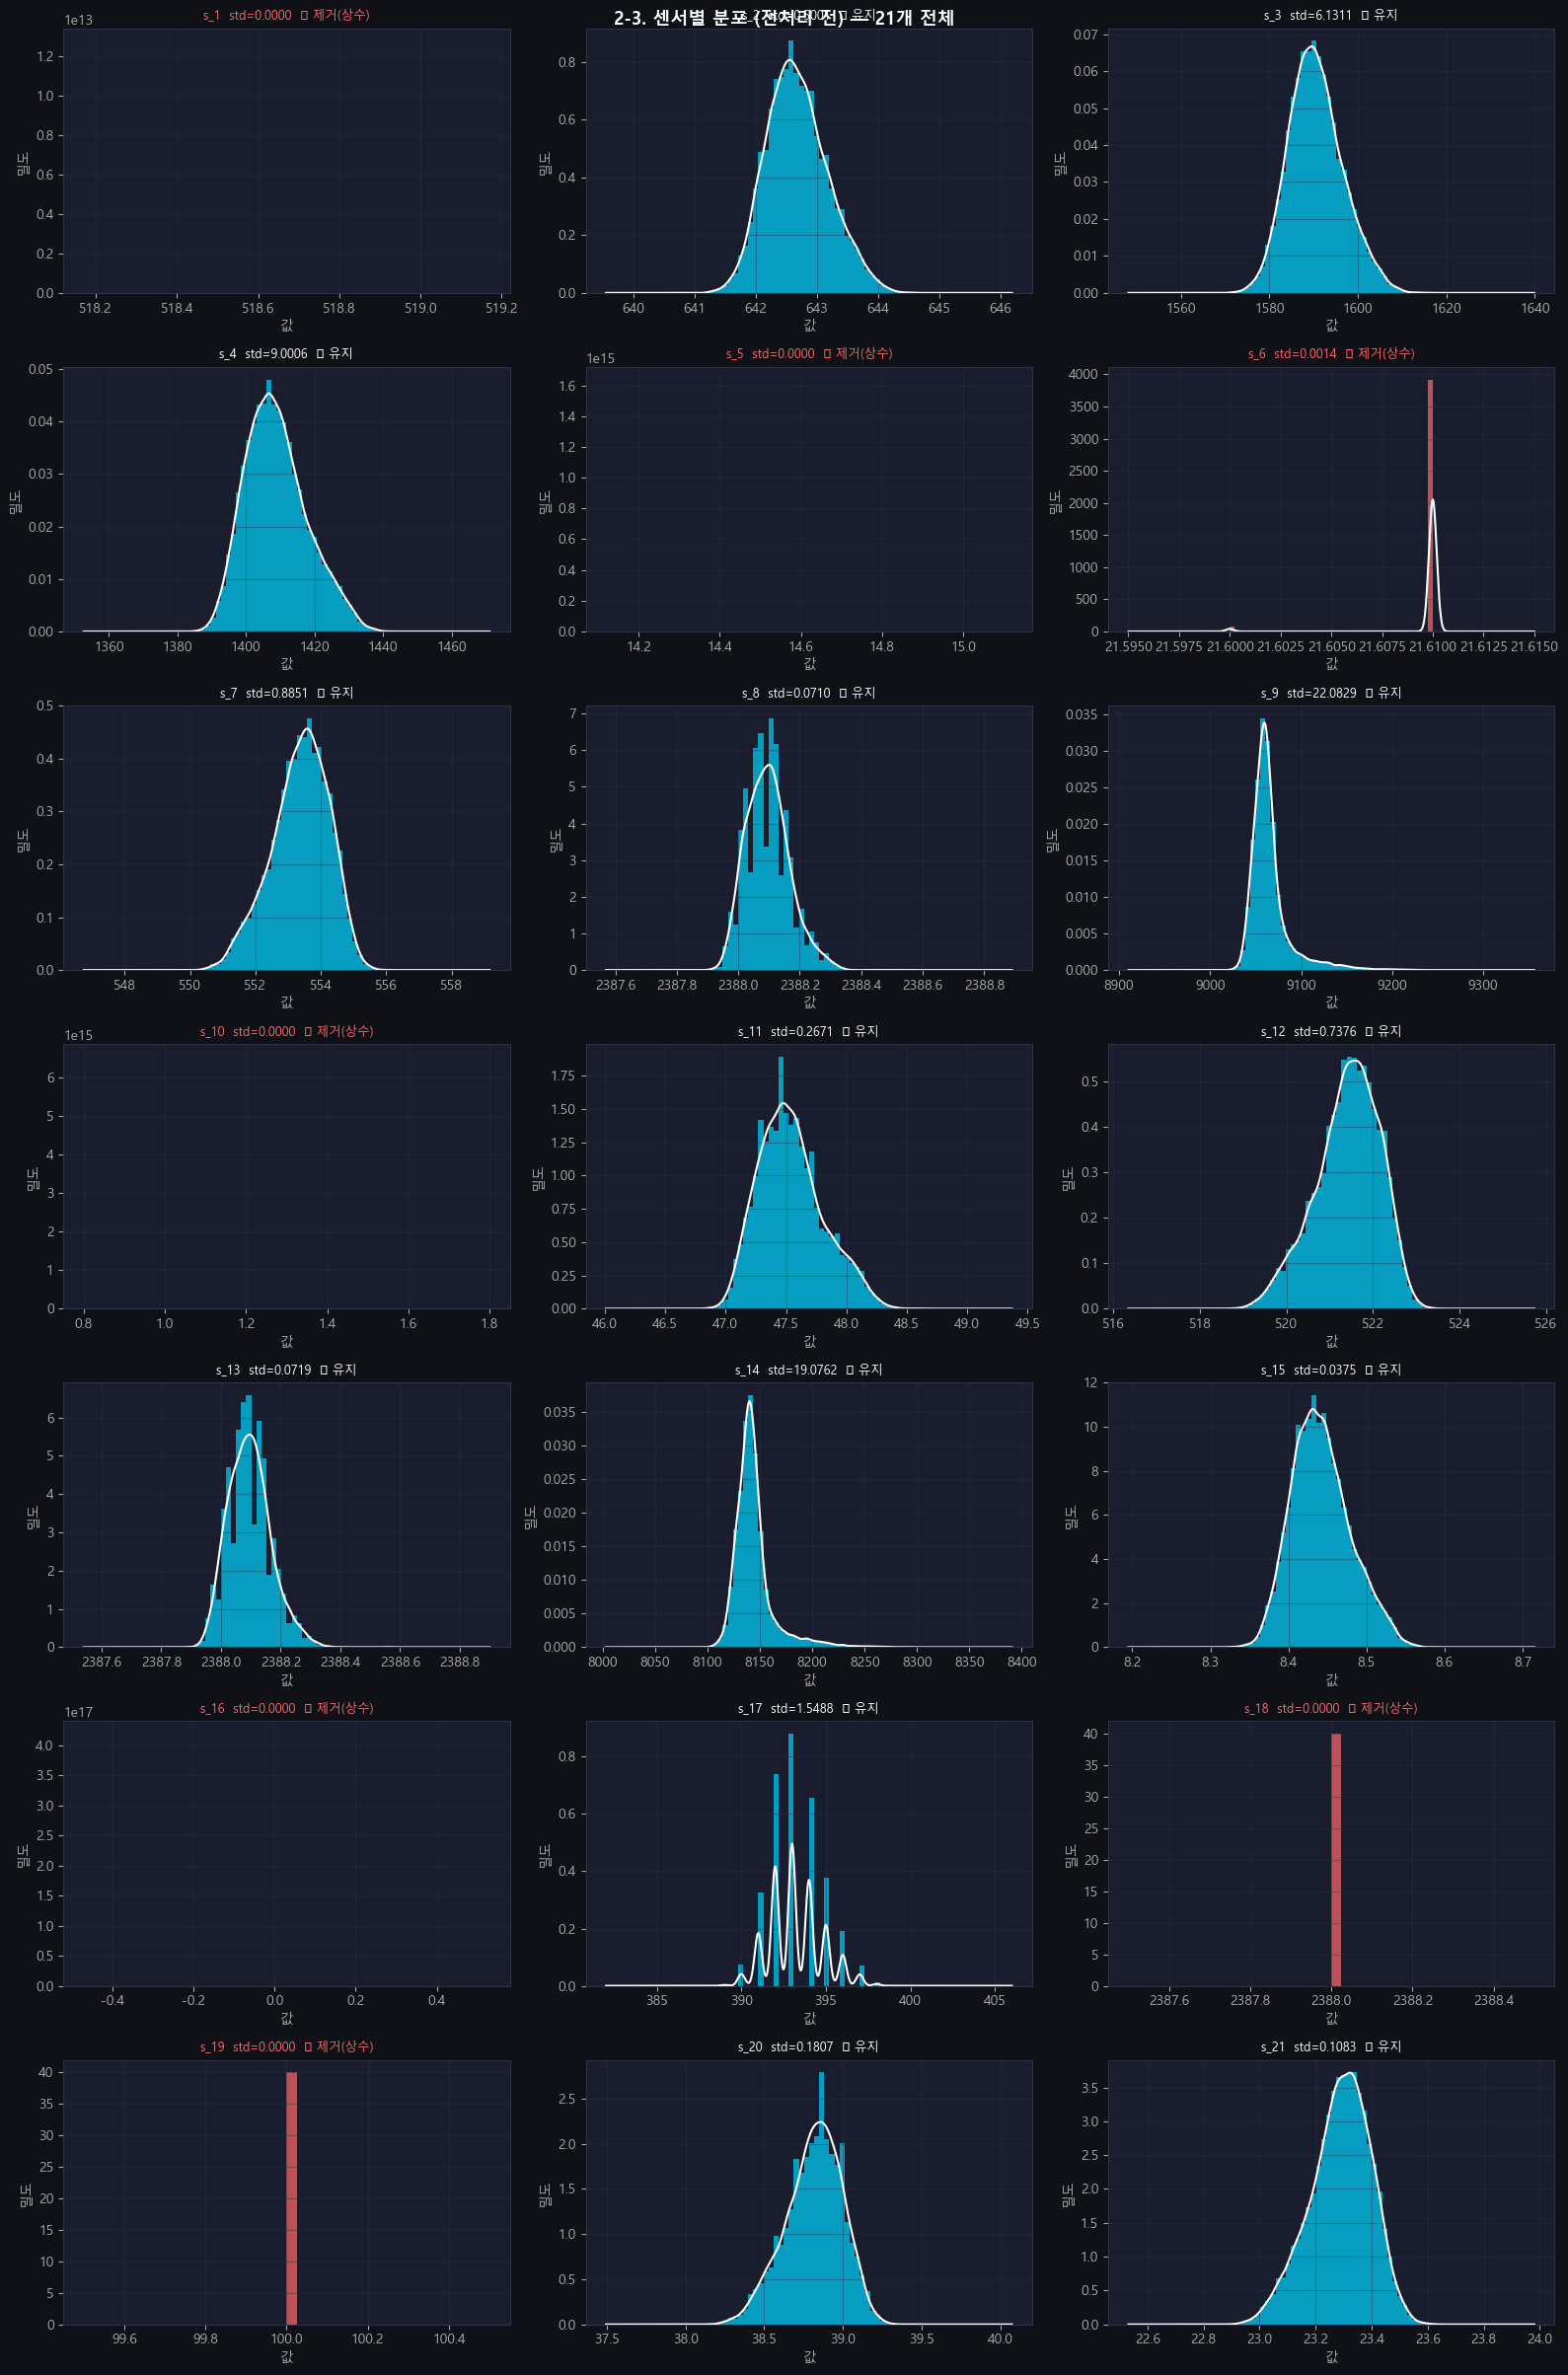

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,128,0.620
2,s_3,165,0.800
3,s_4,120,0.582
5,s_6,406,1.968
6,s_7,110,0.533
7,s_8,320,1.551
8,s_9,1686,8.172
10,s_11,167,0.809
11,s_12,146,0.708
12,s_13,161,0.780


In [5]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 📊 2-3. 센서별 분포 & 이상치 탐지 결과

---

#### 센서 분포 시각화 해석
- **빨간색 센서 (상수, 제거 대상):** s_1, s_5, s_6, s_10, s_16, s_18, s_19
  → 막대가 한 점에만 집중 = 값이 전혀 변하지 않음
- **파란색 센서 (유용, 유지):** 나머지 14개
  → 종 모양 분포 = 값이 다양하게 변함 = 열화 정보 포함 가능

> 💡 s_9, s_14는 분포가 왼쪽으로 치우쳐 있음 (왼쪽 꼬리)
> → 고장 직전 낮아지는 값들이 존재한다는 의미
> → 열화 신호일 가능성 있음 → 이상치로 제거하면 안됨

> 💡 s_8은 다봉분포 형태
> - 다봉분포란? 봉우리가 여러 개인 분포
> - 단봉분포: 값이 하나의 중심으로 모임 (대부분 센서)
> - 다봉분포: 값이 여러 군데로 나뉘어 모임 (s_8)
> - s_8 = Nf 팬 속도(rpm) → 비행 단계(이륙/순항/착륙)마다
>   팬 속도가 달라져서 봉우리가 여러 개 생김
> - FD001은 단일 운전조건이라 이론적으로는 단봉이어야 하는데
>   다봉이 나온 것 → 주의깊게 봐야 할 센서

---

#### IQR 이상치 탐지 결과

| 센서 | 이상치 수 | 비율(%) | 비고 |
|------|---------|---------|------|
| s_9  | 1,686 | 8.172 | 가장 높음 ⚠️ |
| s_14 | 1,543 | 7.479 | 두 번째 ⚠️ |
| s_8  | 320 | 1.551 | 다봉분포 영향 |
| s_6  | 406 | 1.968 | 상수 센서라 제거 예정 |
| 나머지 | 81~167 | 0.4~0.8 | 낮은 수준 |

---

#### 🔑 핵심 결론

**① s_9, s_14 이상치 비율이 높은 이유**
- s_9 = Nc 코어 속도(rpm), s_14 = NRc 보정 코어속도
- 둘의 상관계수 r=0.96 → 거의 같은 정보
- 고장 직전 급격히 낮아지는 값들이 IQR 기준으로 이상치로 잡힘
- 실제로는 열화 신호 → 제거하면 안됨 ✅

**② 전체적으로 이상치 비율이 낮음**
- 대부분 센서 0.4~0.8% 수준
- 시뮬레이션 데이터 특성상 깨끗한 데이터
- 별도 이상치 처리 불필요
- 튜터님 피드백: 이상치 = 열화 신호일 수 있음 → 제거 금지

**③ s_9, s_14 로그 변환 논의 근거**
- 높은 이상치 비율 = 분포가 한쪽으로 치우쳐 있다는 증거
- 단, 제거가 아닌 분포 보정 목적으로만 고려
- 1차 공통 전처리 후 모델 실험 단계에서 결정 예정

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

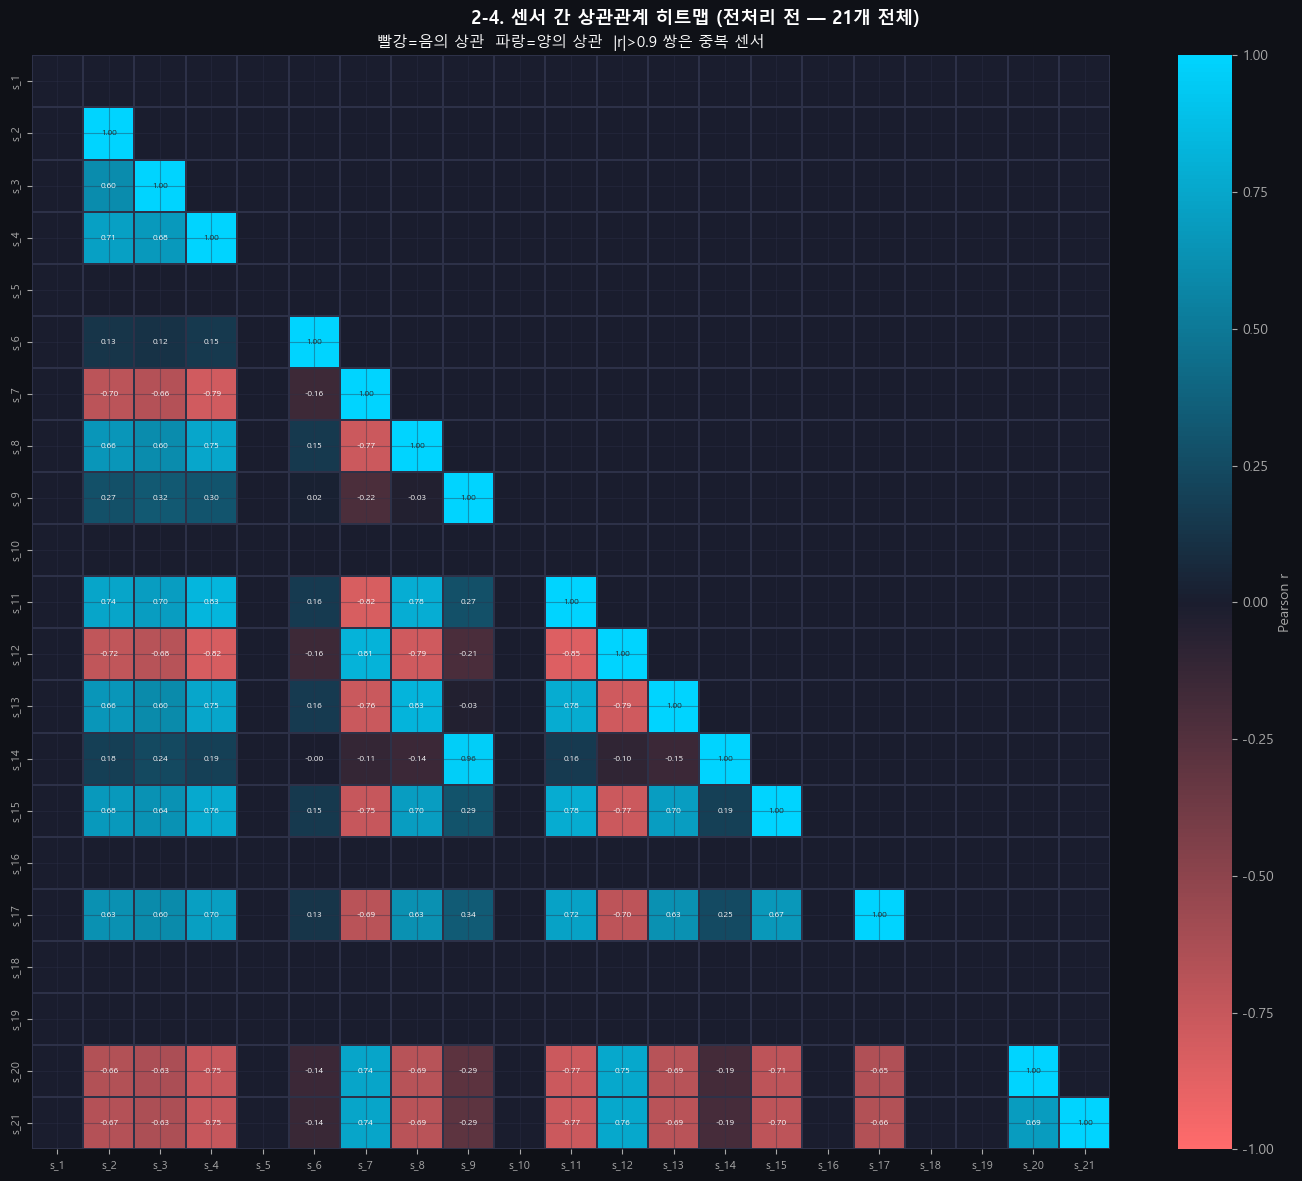

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_9,s_14,0.963


In [6]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 📊 2-4. 센서 간 상관관계 히트맵 결과

---

#### 히트맵 읽는 법
- **색상 의미**
  - 진한 파랑 (r → +1): 양의 상관 → 하나가 오르면 다른 것도 오름
  - 진한 빨강 (r → -1): 음의 상관 → 하나가 오르면 다른 것은 내림
  - 색 없음 (r → 0): 상관 없음 → 두 센서가 독립적으로 움직임
- **숫자**: 피어슨 상관계수 (-1 ~ +1)

---

#### 고상관 센서란?
- **|r| > 0.9** 인 센서 쌍 = 두 센서가 거의 같은 정보를 담고 있음
- 마치 같은 물리 현상을 두 개의 센서가 중복 측정하는 것
- 모델 입장에서 같은 정보가 두 번 들어오는 것 → 다중공선성 문제 가능성

---

#### 고상관 센서 쌍 결과

| 센서A | 센서B | r | 의미 |
|-------|-------|---|------|
| s_9 | s_14 | 0.963 | 거의 같은 정보 |

- s_9 = Nc 코어 속도(rpm)
- s_14 = NRc 보정 코어속도(rpm)
- NRc = NC / √(T입구 / T표준) → s_14는 s_9의 파생변수
- 즉 같은 물리 현상(코어 속도)을 다른 방식으로 측정한 것

---

#### 주요 상관관계 패턴

**양의 상관 (파랑)**
- s_2 ↔ s_3, s_4: 온도 센서들끼리 함께 상승
  → 엔진이 열화될수록 전체 온도가 같이 올라가는 현상

**음의 상관 (빨강)**
- s_7 ↔ s_2, s_3, s_4: 압력과 온도의 반대 관계
  → 온도 상승 시 압력 효율 하락
- s_20, s_21 ↔ s_2, s_3, s_4: 냉각 블리드와 온도의 반대 관계

---

#### 🔑 핵심 결론
> **고상관 쌍: s_9 ↔ s_14 (r=0.963)**
> → 둘 다 유지하면 같은 정보가 중복
> → 단, 논문 표준상 둘 다 유지하고 모델이 알아서 처리하도록 함
> → 추후 피처 중요도 분석에서 재검토 예정

> **상수 센서(s_1, s_5, s_10, s_16, s_18, s_19)는**
> 히트맵에서 색이 없는 구간으로 나타남
> → 다른 센서와 상관관계 자체가 없음 = 제거 근거 재확인

### 2-5. 센서별 열화 트렌드 (전처리 전)

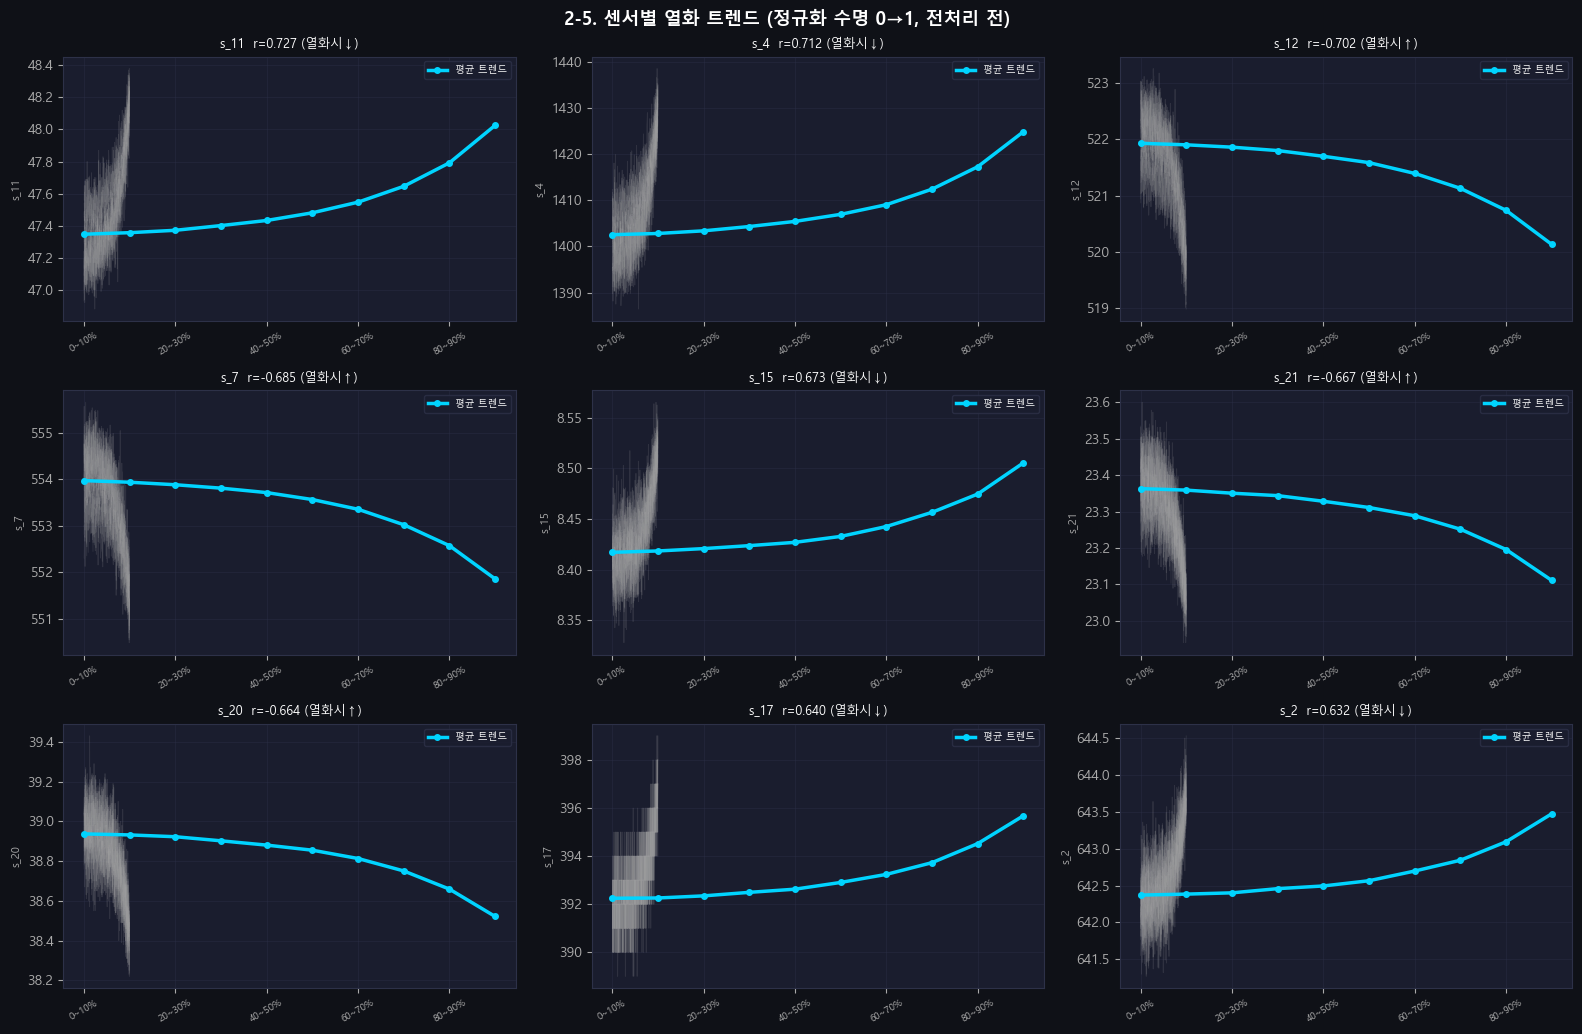

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [7]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 (|corr|>0.1)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]  # 최대 9개

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)
    ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 📊 2-5. 센서별 열화 트렌드 결과

---

#### 그래프 읽는 법
- x축: 정규화 수명 (0~10% = 새 엔진 → 90~100% = 고장 직전)
- y축: 센서값
- 회색 선: 개별 엔진 15개 샘플
- 파란 선: 전체 평균 트렌드
- r < 0: 열화시 센서값 증가 (↑)
- r > 0: 열화시 센서값 감소 (↓)

---

#### 센서별 트렌드 분류

**열화시 증가하는 센서 (r < 0)**
| 센서 | r | 의미 |
|------|---|------|
| s_12 | -0.702 | 연료/압력 비율 상승 → 연료 효율 저하 |
| s_7  | -0.685 | HPC 출구 압력 상승 → 압축기 과부하 |
| s_20 | -0.664 | HPT 냉각블리드 상승 → 냉각 필요 증가 |

**열화시 감소하는 센서 (r > 0)**
| 센서 | r | 의미 |
|------|---|------|
| s_11 | 0.727 | 정적압력 감소 → 압력 손실 증가 |
| s_4  | 0.712 | LPT 출구 온도 감소 → 터빈 효율 저하 |
| s_15 | 0.673 | 바이패스 비율 감소 → 엔진 효율 저하 |
| s_21 | 0.667 | LPT 냉각블리드 감소 |
| s_17 | 0.640 | 블리드 엔탈피 감소 |
| s_2  | 0.632 | LPC 출구 온도 감소 |

---

#### 🔑 핵심 포인트

**① 초반 구간(0~20%) 패턴**
- 모든 센서에서 초반에 회색 선이 좁게 뭉쳐있음
- 정상 운전 구간 → 센서값이 안정적
- Cap=125 설정 근거 재확인
  → 이 구간은 RUL 예측에 의미 없음

**② 후반 구간(80~100%) 패턴**
- 평균 트렌드(파란 선)가 급격히 변화
- 열화가 가속되는 구간
- 이 구간의 패턴 학습이 RUL 예측의 핵심

**③ 대응 표본 t검정 근거**
- 수명 80% 전후로 센서값이 눈에 띄게 달라짐
- → 통계적으로 유의미한 차이인지 검정 예정

### 2-6. RUL 상관계수 (전처리 전)

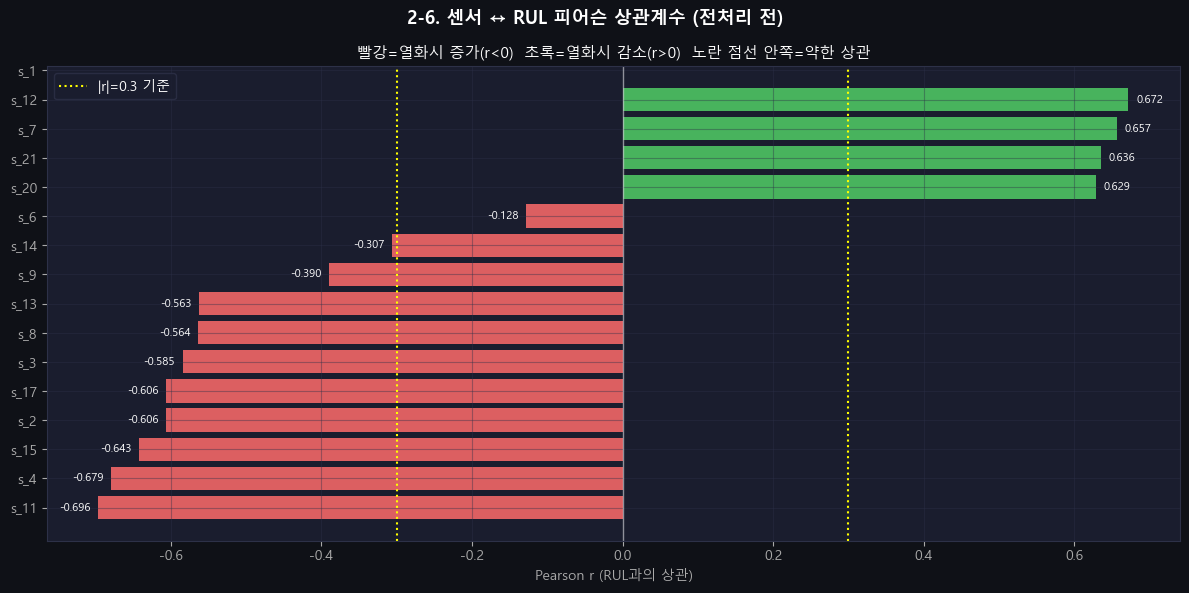

|r|>0.3 고상관 센서: 14개
  s_11: r=-0.696  Ps30 정적압력(psia)
  s_4: r=-0.679  T50 LPT 출구 온도(°R)
  s_12: r=0.672  phi 연료/Ps30 비율
  s_7: r=0.657  P30 HPC 출구 압력(psia)
  s_15: r=-0.643  BPR 바이패스 비율
  s_21: r=0.636  W32 LPT 냉각블리드
  s_20: r=0.629  W31 HPT 냉각블리드
  s_2: r=-0.606  T24 LPC 출구 온도(°R)
  s_17: r=-0.606  htBleed 블리드 엔탈피
  s_3: r=-0.585  T30 HPC 출구 온도(°R)
  s_8: r=-0.564  Nf 팬 속도(rpm)
  s_13: r=-0.563  NRf 보정 팬 속도(rpm)
  s_9: r=-0.390  Nc 코어 속도(rpm)
  s_14: r=-0.307  NRc 보정 코어속도(rpm)


In [9]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 📊 2-6. 센서 ↔ RUL 피어슨 상관계수 결과 (전처리 전)

---

#### 그래프 읽는 법
- **빨간 막대 (r < 0):** 열화시 센서값 증가
  → RUL이 줄어들수록(고장 가까울수록) 센서값이 올라감
- **초록 막대 (r > 0):** 열화시 센서값 감소
  → RUL이 줄어들수록 센서값이 내려감
- **노란 점선 (|r| = 0.3):** 이 안쪽은 RUL과 상관이 약한 센서

---

#### 고상관 센서 (|r| > 0.3) — 총 14개

**열화시 증가하는 센서 (빨간 막대)**
| 센서 | r | 물리적 의미 |
|------|---|------------|
| s_11 | -0.696 | Ps30 정적압력 → 열화시 압력 상승 |
| s_4  | -0.679 | T50 LPT 출구 온도 → 열화시 온도 상승 |
| s_15 | -0.643 | BPR 바이패스 비율 → 열화시 증가 |
| s_2  | -0.606 | T24 LPC 출구 온도 → 열화시 온도 상승 |
| s_17 | -0.606 | htBleed 블리드 엔탈피 → 열화시 증가 |
| s_3  | -0.585 | T30 HPC 출구 온도 → 열화시 온도 상승 |
| s_8  | -0.564 | Nf 팬 속도 → 열화시 증가 |
| s_13 | -0.563 | NRf 보정 팬 속도 → 열화시 증가 |
| s_9  | -0.390 | Nc 코어 속도 → 열화시 증가 |
| s_14 | -0.307 | NRc 보정 코어속도 → 열화시 증가 |

**열화시 감소하는 센서 (초록 막대)**
| 센서 | r | 물리적 의미 |
|------|---|------------|
| s_12 | 0.672 | phi 연료/Ps30 비율 → 열화시 감소 |
| s_7  | 0.657 | P30 HPC 출구 압력 → 열화시 압력 감소 |
| s_21 | 0.636 | W32 LPT 냉각블리드 → 열화시 감소 |
| s_20 | 0.629 | W31 HPT 냉각블리드 → 열화시 감소 |

---

#### 🔑 핵심 결론

**① 상수 센서는 상관계수가 거의 0**
- s_1, s_5, s_6, s_10, s_16, s_18, s_19
- → 제거 근거 재확인 ✅

**② 유용 센서 14개 전부 |r| > 0.3**
- 모두 RUL과 유의미한 상관관계
- → 14개 센서 전부 모델 입력으로 사용 근거 ✅

**③ s_9, s_14 상관계수가 상대적으로 낮음**
- s_9: r=-0.390, s_14: r=-0.307
- 다른 센서 대비 RUL과의 직접 상관이 약함
- 단, 고상관 쌍(r=0.963)이므로 중복 정보 포함
- → 추후 피처 중요도 분석에서 재검토 예정

> 💡 다음 단계: 스피어만 상관계수, Mann-Kendall,
> 대응 표본 t검정으로 통계적 유의성 검증 예정

# 전처리 전 통계는 제 것으로 그대로 썼습니다~!

### 3. 통계 검정

---

#### 검정 목적
EDA에서 시각적으로 확인한 패턴들을 **통계적으로 증명**하는 단계

| 검정 | 목적 |
|------|------|
| 3-1. 시차 상관관계 (Lag Correlation) | 몇 사이클 전 센서값이 RUL과 가장 연관있는지 확인 → 슬라이딩 윈도우 크기(30) 근거 |
| 3-2. Mann-Kendall | 센서값의 열화 트렌드가 통계적으로 유의미한지 검정 |
| 3-3. 대응 표본 t검정 | 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정 |

---

#### 가설

**3-1. 시차 상관관계**
- H₀: 과거 센서값과 현재 RUL 사이에 상관관계가 없다
- H₁: 특정 시차(lag)에서 센서값과 RUL 사이에 유의미한 상관관계가 있다

**3-2. Mann-Kendall**
- H₀: 센서값에 단조 트렌드가 없다 (랜덤하게 변한다)
- H₁: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)

**3-3. 대응 표본 t검정**
- H₀: 수명 80% 이전과 이후 구간의 센서 평균에 차이가 없다
- H₁: 수명 80% 이후 구간에서 센서 평균이 유의미하게 달라진다

> 💡 모든 검정의 유의수준: α = 0.05
> p-value < 0.05 → H₀ 기각 → H₁ 채택

=== 3-1. 시차 상관관계 (Lag Correlation) ===


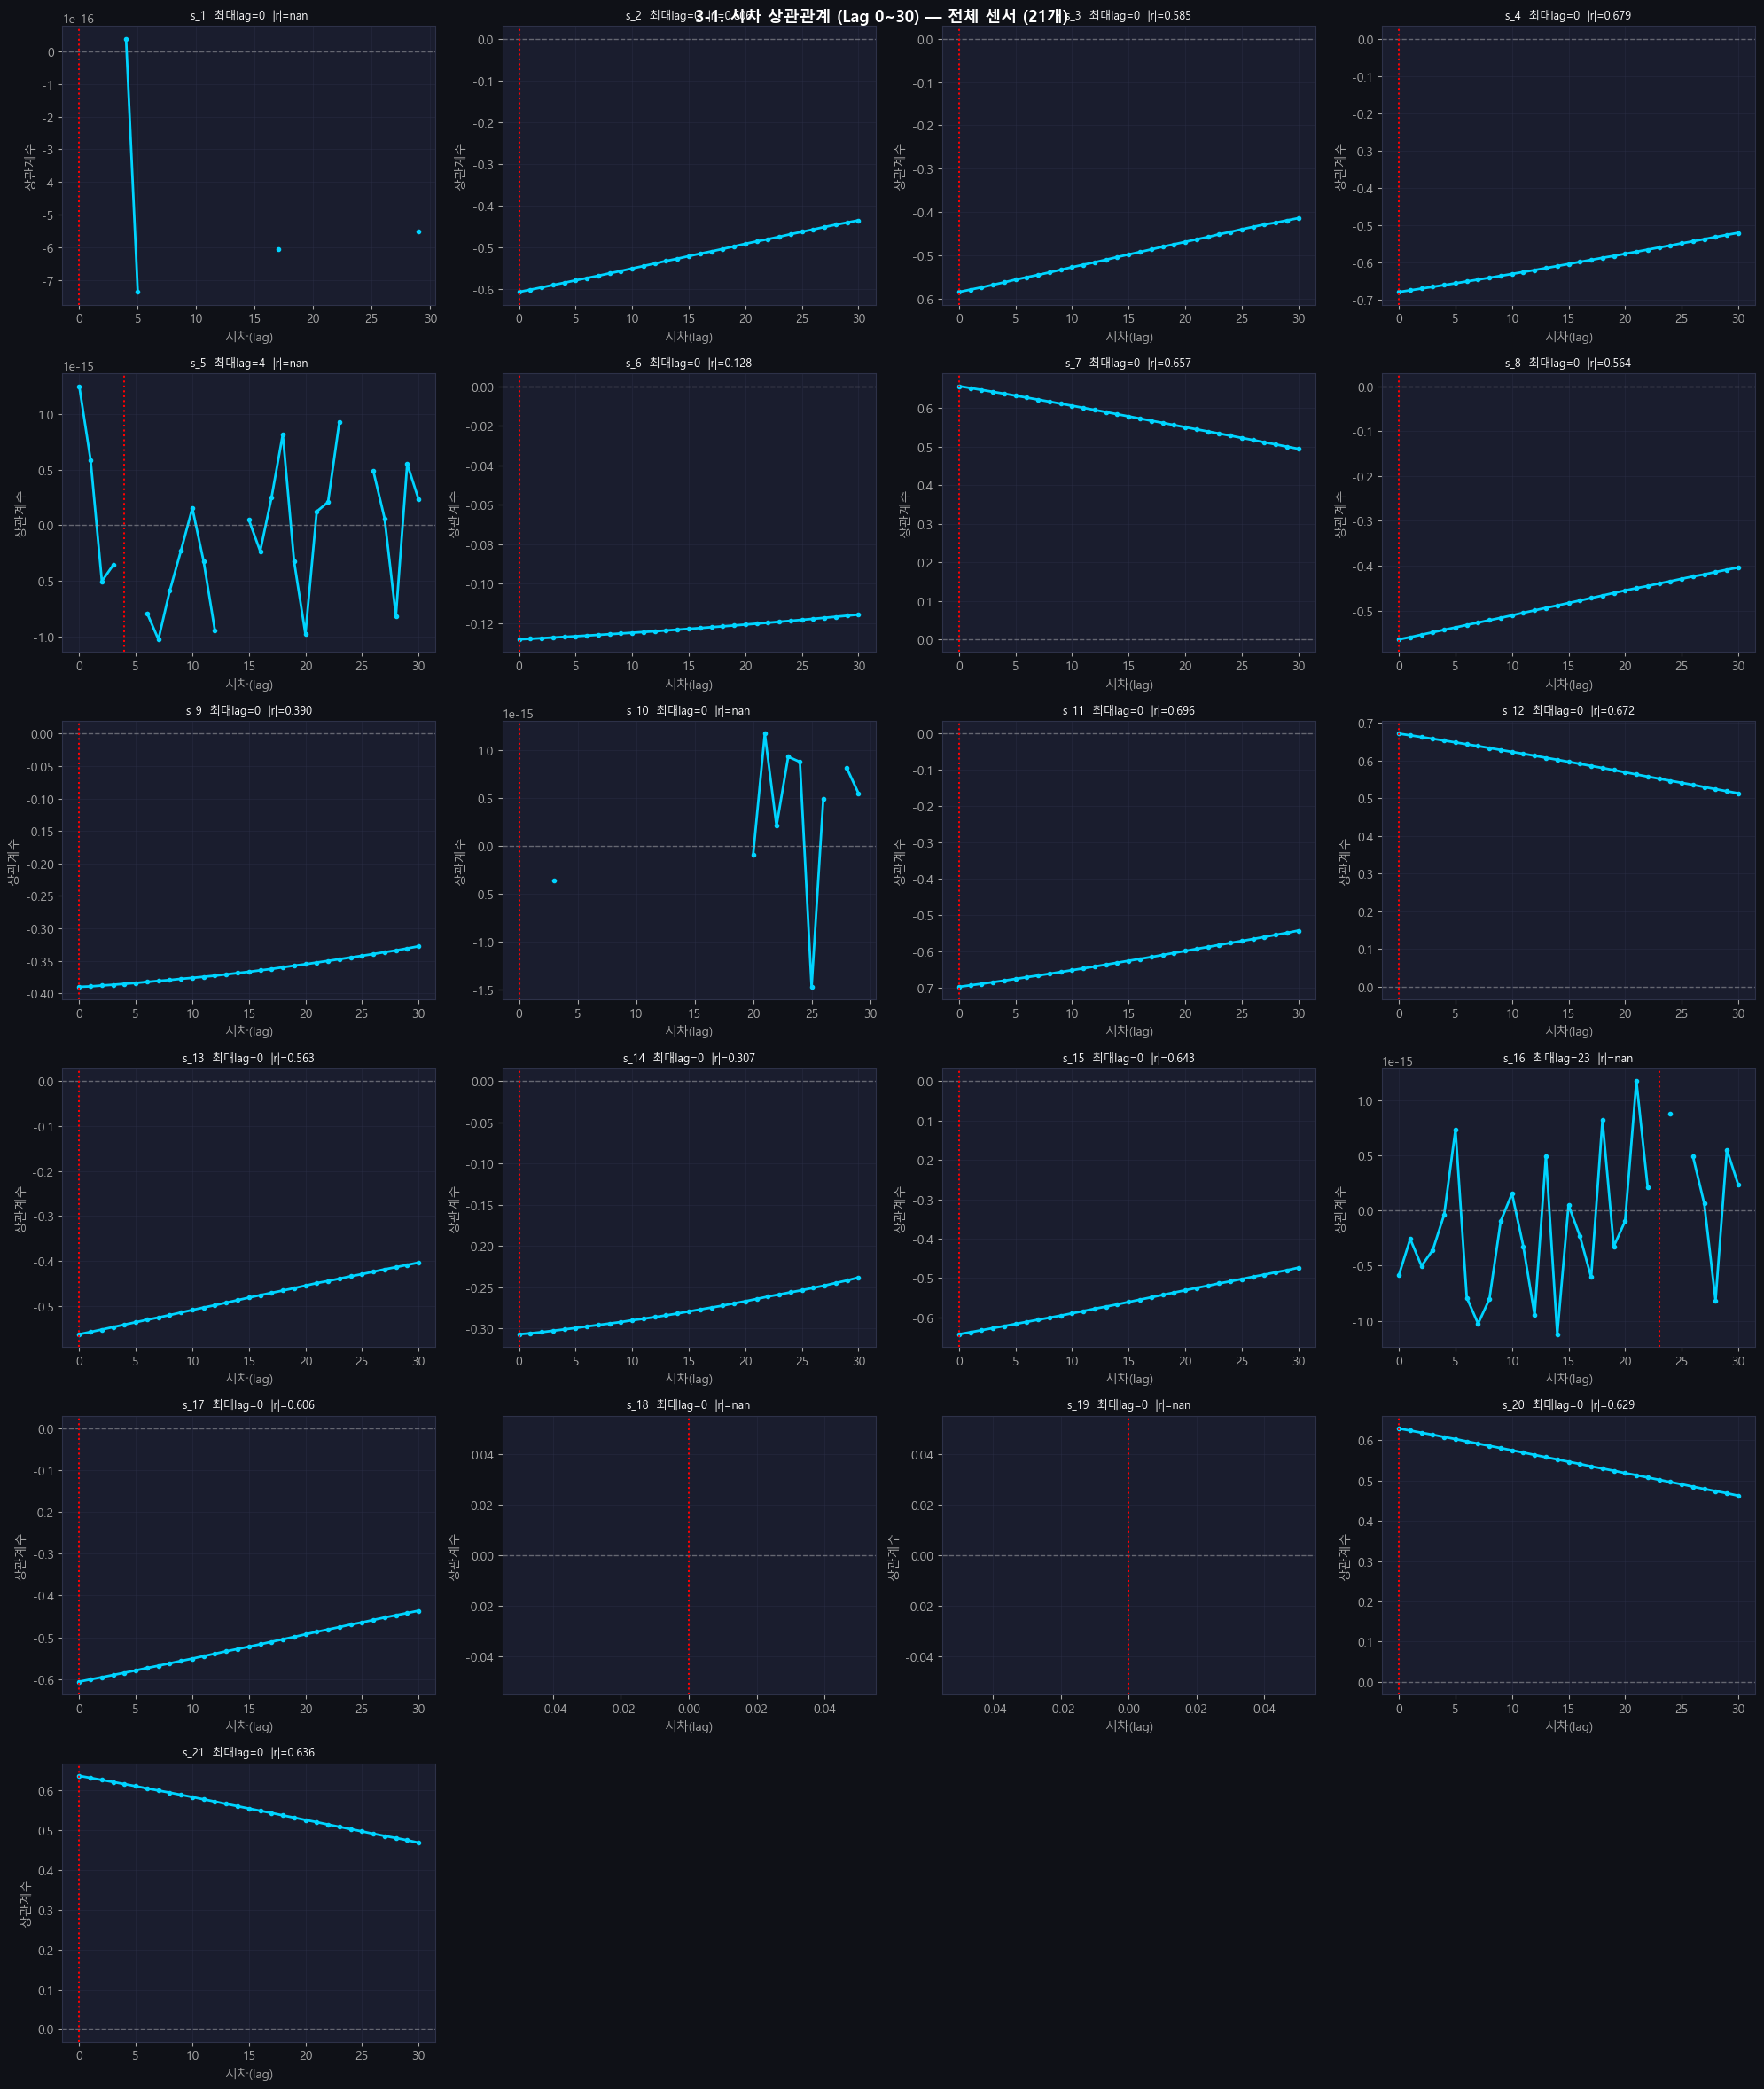


=== 센서별 최적 시차 요약 ===
  s_1: lag=0사이클에서 최대 상관 (r=nan)
  s_2: lag=0사이클에서 최대 상관 (r=-0.606)
  s_3: lag=0사이클에서 최대 상관 (r=-0.585)
  s_4: lag=0사이클에서 최대 상관 (r=-0.679)
  s_5: lag=4사이클에서 최대 상관 (r=nan)
  s_6: lag=0사이클에서 최대 상관 (r=-0.128)
  s_7: lag=0사이클에서 최대 상관 (r=0.657)
  s_8: lag=0사이클에서 최대 상관 (r=-0.564)
  s_9: lag=0사이클에서 최대 상관 (r=-0.390)
  s_10: lag=0사이클에서 최대 상관 (r=nan)
  s_11: lag=0사이클에서 최대 상관 (r=-0.696)
  s_12: lag=0사이클에서 최대 상관 (r=0.672)
  s_13: lag=0사이클에서 최대 상관 (r=-0.563)
  s_14: lag=0사이클에서 최대 상관 (r=-0.307)
  s_15: lag=0사이클에서 최대 상관 (r=-0.643)
  s_16: lag=23사이클에서 최대 상관 (r=nan)
  s_17: lag=0사이클에서 최대 상관 (r=-0.606)
  s_18: lag=0사이클에서 최대 상관 (r=nan)
  s_19: lag=0사이클에서 최대 상관 (r=nan)
  s_20: lag=0사이클에서 최대 상관 (r=0.629)
  s_21: lag=0사이클에서 최대 상관 (r=0.636)


In [10]:
# 3-1. 시차 상관관계 (Lag Correlation)
print('=== 3-1. 시차 상관관계 (Lag Correlation) ===')

all_sensors = [f's_{i}' for i in range(1, 22)]
tr_lag = train_raw.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']


max_lag = 30  # 슬라이딩 윈도우 크기와 동일
lag_results = {}

for s in all_sensors:
    lag_corrs = []
    for lag in range(0, max_lag + 1):
        shifted = tr_lag.groupby('unit_nr')[s].shift(lag)
        valid = ~shifted.isna()
        r = tr_lag.loc[valid, 'RUL'].corr(shifted[valid])
        lag_corrs.append(r)
    lag_results[s] = lag_corrs

# 시각화
n_cols = 4
n_rows = (len(all_sensors) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('3-1. 시차 상관관계 (Lag 0~30) — 전체 센서 (21개)', 
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, all_sensors):
    lag_corrs = lag_results[s]
    best_lag = int(np.argmax(np.abs(lag_corrs)))
    best_r   = lag_corrs[best_lag]
    ax.plot(range(max_lag + 1), lag_corrs, 
            color=C[0], lw=2, marker='o', markersize=3)
    ax.axhline(0, color=GRAY, ls='--', lw=1, alpha=0.5)
    ax.axvline(best_lag, color='red', ls=':', lw=1.5)
    ax.set_title(f'{s}  최대lag={best_lag}  |r|={abs(best_r):.3f}', fontsize=9)
    ax.set_xlabel('시차(lag)')
    ax.set_ylabel('상관계수')

for ax in axes.flat[len(all_sensors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n=== 센서별 최적 시차 요약 ===')
for s in all_sensors:
    best_lag = int(np.argmax(np.abs(lag_results[s])))
    best_r   = lag_results[s][best_lag]
    print(f'  {s}: lag={best_lag}사이클에서 최대 상관 (r={best_r:.3f})')

### 3-1. 시차 상관관계 결과

---

### 상관계수 방향 해석

- **r < 0 (음의 상관)**: RUL이 줄어들수록 센서값이 올라감 → 고장에 가까워질수록 센서값 증가↑
- **r > 0 (양의 상관)**: RUL이 줄어들수록 센서값도 내려감 → 고장에 가까워질수록 센서값 감소↓

---

### 결과 해석

- **유의미한 상관관계가 있는 센서에서 모두 lag=0이 최대 상관**
- lag가 커질수록 상관계수가 점점 약해지는 패턴

---

### 센서별 최적 시차 요약

| 센서 | 최적 lag | r | 방향 |
|------|---------|---|------|
| s_11 | 0 | -0.696 | RUL 감소 → 센서값 증가↑ |
| s_4  | 0 | -0.679 | RUL 감소 → 센서값 증가↑ |
| s_15 | 0 | -0.643 | RUL 감소 → 센서값 증가↑ |
| s_2  | 0 | -0.606 | RUL 감소 → 센서값 증가↑ |
| s_17 | 0 | -0.606 | RUL 감소 → 센서값 증가↑ |
| s_3  | 0 | -0.585 | RUL 감소 → 센서값 증가↑ |
| s_8  | 0 | -0.564 | RUL 감소 → 센서값 증가↑ |
| s_13 | 0 | -0.563 | RUL 감소 → 센서값 증가↑ |
| s_9  | 0 | -0.390 | RUL 감소 → 센서값 증가↑ |
| s_14 | 0 | -0.307 | RUL 감소 → 센서값 증가↑ |
| s_12 | 0 | 0.672  | RUL 감소 → 센서값 감소↓ |
| s_7  | 0 | 0.657  | RUL 감소 → 센서값 감소↓ |
| s_21 | 0 | 0.636  | RUL 감소 → 센서값 감소↓ |
| s_20 | 0 | 0.629  | RUL 감소 → 센서값 감소↓ |
| s_6  | 0 | -0.128 | 상관관계 매우 낮음 → 열화 정보 부족 |
| s_1, s_5, s_10, s_16, s_18, s_19 | — | NaN | 상수 센서 → 상관관계 계산 불가 |

---

### 🔑 핵심 결론

① **유의미한 센서에서 모두 lag=0에서 최대 상관**
- 과거 값보다 현재 값이 RUL을 가장 잘 설명함
- 센서가 열화를 실시간으로 반영하고 있다는 의미

② **lag가 커질수록 상관이 약해짐**
- 그러나 lag=30까지도 상관관계가 유지됨
- → 과거 30사이클치 데이터가 여전히 유효한 정보를 담고 있음
- → **슬라이딩 윈도우 크기 30 설정의 근거** ✅

③ **상수 센서 6개 자연 탈락 확인**
- s_1, s_5, s_10, s_16, s_18, s_19 → r=NaN → 값이 변하지 않아 상관관계 계산 자체 불가
- → **상수 센서 제거 근거 통계적으로 재확인**

④ **H₁ 채택**
- 유의미한 14개 센서에서 lag=0 기준 유의미한 상관관계 확인
- → 과거 센서값과 현재 RUL 사이에 상관관계가 존재함
- → H₀ 기각: 과거 센서값과 현재 RUL 사이에 상관관계가 없다 ❌

---

## 3-2. Mann-Kendall 추세 검정 ( 수정 후 버전임_ 민준님 코드를 참고해서 보완함)

---

### 검정 목적

센서값이 시간에 따라 단조롭게 증가 또는 감소하는 추세가 통계적으로 유의미한지 검정

> 엔진 1개가 아닌 **FD001 전체 100개 엔진**을 대상으로 검정하여 결과의 신뢰도를 높임

---

### 추세란?

시간이 지남에 따라 전체적으로 한 방향으로 변하는 경향 — 오르락내리락 해도 전체적인 방향성이 있으면 추세 있음

**추세 있음 (우상향)**
- 사이클: 1 2 3 4 5 6 7
- 센서값: 100 102 99 103 101 105 104
- → 오르락내리락 하지만 전체적으로 증가

**추세 없음 (방향성 없음)**
- 사이클: 1 2 3 4 5 6 7
- 센서값: 100 103 98 105 99 102 101
- → 오르락내리락 하고 방향성 없음 (노이즈)

---

### 우리 데이터에서 의미

- **추세 있음** → 엔진이 닳아갈수록 센서값이 체계적으로 변함 → 열화 정보를 담고 있음 → RUL 예측에 유효한 센서 ✅
- **추세 없음** → 센서값이 랜덤하게 움직이는 것 → 열화 정보를 담고 있지 않음 → RUL 예측에 기여 못함 ❌

> 단, 엔진 1개에서만 추세가 확인되면 그 엔진의 특수한 패턴일 수 있음  
> **100개 엔진 전체에서 반복적으로 추세가 나타나는 센서**만 진정한 열화 신호로 볼 수 있음

---

### 가설

- **H₀**: 센서값에 단조 추세가 없다 (랜덤하게 변한다)
- **H₁**: 센서값에 유의미한 단조 추세가 있다 (열화 신호 존재)

💡 유의수준: α = 0.05 — p-value < 0.05 → H₀ 기각 → 추세 존재 통계적 증명

> 100개 엔진 각각에 대해 검정 후, **90% 이상(90개 이상)의 엔진에서 유의미한 추세**가 확인된 센서를 열화 신호 센서로 판정

---

### 켄달 타우(τ) 해석

- τ > 0: 시간이 지날수록 센서값 증가
- τ < 0: 시간이 지날수록 센서값 감소
- **|τ| 클수록 추세가 강함**

> 100개 엔진의 평균 τ를 사용하여 센서별 전반적인 추세 방향과 강도를 파악

=== 3-2. Mann-Kendall 추세 검정 (전체 엔진) ===


,유효 엔진 수,추세 있는 엔진 수,비율(%),평균 τ,추세 방향,판정
센서,,,,,,
s_2,100,100,100.0,0.4826,증가↑,추세 있음✅
s_3,100,100,100.0,0.4527,증가↑,추세 있음✅
s_4,100,100,100.0,0.5889,증가↑,추세 있음✅
s_7,100,100,100.0,-0.5695,감소↓,추세 있음✅
s_17,100,100,100.0,0.5220,증가↑,추세 있음✅
s_12,100,100,100.0,-0.6033,감소↓,추세 있음✅
s_11,100,100,100.0,0.6336,증가↑,추세 있음✅
s_20,100,100,100.0,-0.5228,감소↓,추세 있음✅
s_21,100,100,100.0,-0.5183,감소↓,추세 있음✅


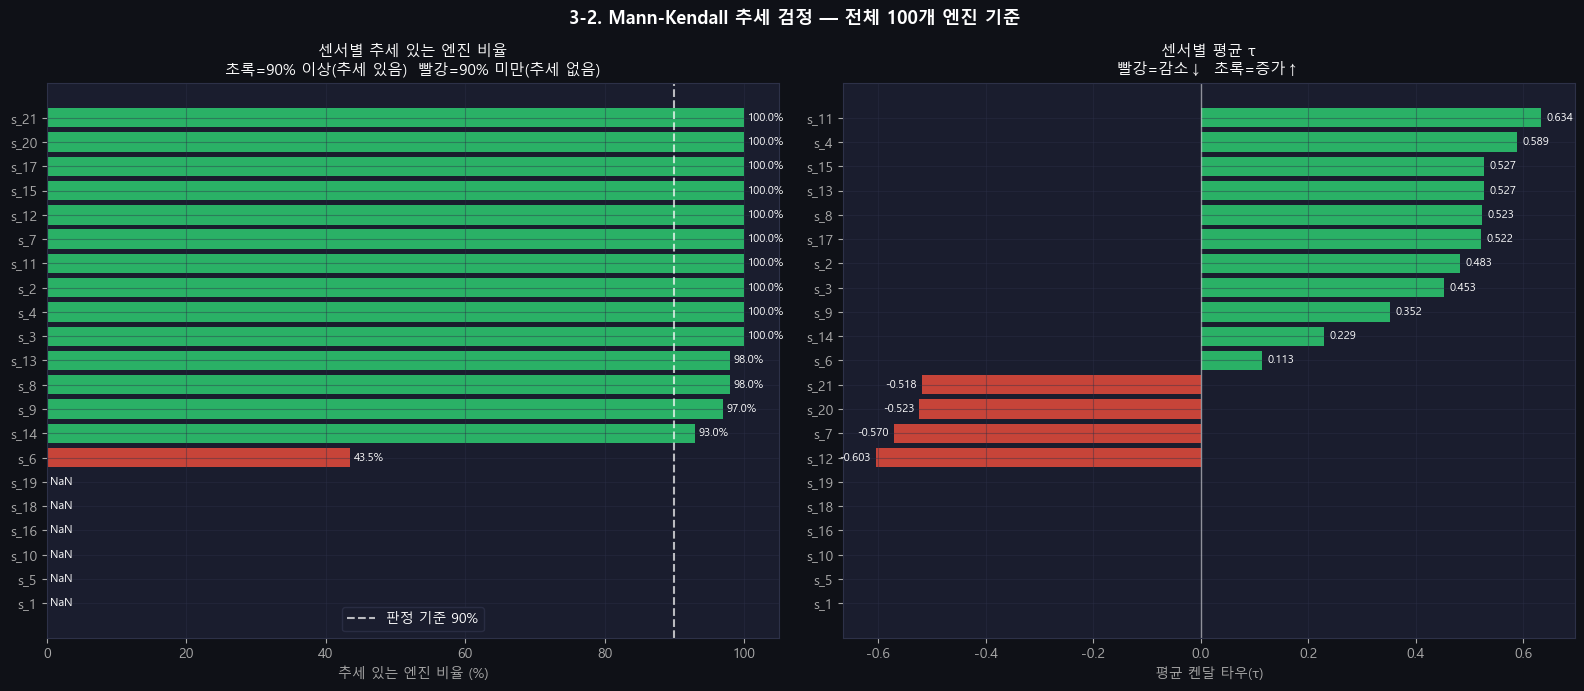


90% 이상 엔진에서 추세 있는 센서: 14/21개


In [13]:
from scipy.stats import kendalltau

print('=== 3-2. Mann-Kendall 추세 검정 (전체 엔진) ===')

all_units = train_raw['unit_nr'].unique()  # 100개 엔진
results = {s: [] for s in all_sensors}

for unit in all_units:
    unit_df = train_raw[train_raw['unit_nr'] == unit].sort_values('time_cycles')
    for s in all_sensors:
        arr = unit_df[s].values
        time_idx = np.arange(len(arr))
        tau, p_val = kendalltau(time_idx, arr)
        if np.isfinite(tau):  # NaN 제외
            results[s].append({'tau': tau, 'p_val': p_val})

# 센서별 집계
mk_rows = []
for s in all_sensors:
    taus = [r['tau'] for r in results[s]]
    p_vals = [r['p_val'] for r in results[s]]
    n_valid = len(results[s])  # 유효한 엔진 수 (NaN 제외)
    n_significant = sum(p < 0.05 for p in p_vals)
    
    sig_ratio = n_significant / n_valid if n_valid > 0 else np.nan
    
    mk_rows.append({
        '센서': s,
        '유효 엔진 수': n_valid,
        '추세 있는 엔진 수': n_significant,
        '비율(%)': round(sig_ratio * 100, 1) if np.isfinite(sig_ratio) else np.nan,
        '평균 τ': round(np.mean(taus), 4) if taus else np.nan,
        '추세 방향': '증가↑' if np.mean(taus) > 0 else '감소↓' if taus else '-',
        '판정': '추세 있음✅' if np.isfinite(sig_ratio) and sig_ratio >= 0.9 else '추세 없음⚠️'
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.sort_values('비율(%)', ascending=False, na_position='last'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-2. Mann-Kendall 추세 검정 — 전체 100개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: 추세 있는 엔진 비율
mk_sorted = mk_df.sort_values('비율(%)', ascending=True, na_position='first')  # NaN 맨 아래
ratio_vals = mk_sorted['비율(%)'].fillna(0).values  # 시각화용만 0으로 대체
colors_ratio = ['#e74c3c' if (pd.isna(v) or v < 90) else '#2ecc71'
                for v in mk_sorted['비율(%)']]
axes[0].barh(mk_sorted.index, ratio_vals, color=colors_ratio, alpha=0.85)
axes[0].axvline(90, color='white', lw=1.5, linestyle='--', alpha=0.7, label='판정 기준 90%')
axes[0].set_xlabel('추세 있는 엔진 비율 (%)')
axes[0].set_title('센서별 추세 있는 엔진 비율\n초록=90% 이상(추세 있음)  빨강=90% 미만(추세 없음)')
axes[0].legend()
for bar, val in zip(axes[0].patches, mk_sorted['비율(%)']):
    label = f'{val}%' if pd.notna(val) else 'NaN'
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=8)

# 오른쪽: 평균 켄달 타우
mk_sorted2 = mk_df.sort_values('평균 τ', ascending=True, na_position='first')  # NaN 맨 아래
tau_vals = mk_sorted2['평균 τ'].fillna(0).values  # 시각화용만 0으로 대체
colors_tau = ['#e74c3c' if (pd.isna(v) or v < 0) else '#2ecc71'
              for v in mk_sorted2['평균 τ']]
axes[1].barh(mk_sorted2.index, tau_vals, color=colors_tau, alpha=0.85)
axes[1].axvline(0, color='white', lw=1, alpha=0.5)
axes[1].set_xlabel('평균 켄달 타우(τ)')
axes[1].set_title('센서별 평균 τ\n빨강=감소↓  초록=증가↑')
for bar, val in zip(axes[1].patches, mk_sorted2['평균 τ']):
    if pd.isna(val):
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

n_trend = (mk_df['비율(%)'] >= 90).sum()
print(f'\n90% 이상 엔진에서 추세 있는 센서: {n_trend}/21개')

### 검정 결과 해석

---

#### 전체 요약

- 검정 대상: FD001 전체 100개 엔진 × 21개 센서
- 판정 기준: 90개 이상의 엔진(90%)에서 p-value < 0.05 → 추세 있음
- 결과: **14/21개 센서에서 유의미한 추세 확인**

---

#### 추세 있는 센서 (14개) ✅

| 그룹 | 센서 | 비율 | 평균 τ | 추세 방향 |
|------|------|------|--------|-----------|
| 100% | s_2, s_3, s_4, s_7, s_11, s_12, s_15, s_17, s_20, s_21 | 100.0% | — | 센서별 상이 |
| 98%  | s_8, s_13 | 98.0% | +0.523, +0.527 | 증가↑ |
| 97%  | s_9 | 97.0% | +0.352 | 증가↑ |
| 93%  | s_14 | 93.0% | +0.229 | 증가↑ |

- 100% 그룹 10개 센서는 **단 한 개의 예외 엔진도 없이** 전체에서 추세 확인
- s_8, s_13, s_9, s_14는 100%는 아니지만 93% 이상으로 충분히 신뢰할 수 있는 추세

---

#### 추세 없는 센서 (7개) ❌

| 센서 | 비율 | 특이사항 |
|------|------|---------|
| s_6  | 43.5% | 일부 엔진에서 추세가 나타나지만 전체적으로 불안정 (NaN 제외 후 유효 62개 엔진 기준) |
| s_1, s_5, s_10, s_16, s_18, s_19 | NaN | 평균 τ = NaN → 모든 엔진에서 값이 일정 (상수 센서) |

- s_1, s_5, s_10, s_16, s_18, s_19: 평균 τ가 NaN → 센서값이 변하지 않아 켄달 타우 계산 자체가 불가능
  → **상수 센서임을 통계적으로도 재확인**
- s_6: 유효 엔진 62개 기준 43.5%로 추세 없음 판정 → 열화 신호로 보기엔 불충분

---

#### 추세 방향 해석

**시간이 지날수록 증가하는 센서 (τ > 0)**
- s_2, s_3, s_4, s_8, s_9, s_11, s_13, s_14, s_15, s_17
- 엔진이 열화될수록 해당 센서값이 상승 → 마모, 온도 상승, 압력 증가 등 열화 징후 반영

**시간이 지날수록 감소하는 센서 (τ < 0)**
- s_7, s_12, s_20, s_21
- 엔진이 열화될수록 해당 센서값이 하락 → 효율 저하, 유량 감소 등 열화 징후 반영
- 특히 s_12(τ = -0.603), s_7(τ = -0.570)은 절댓값이 커서 **추세 강도가 가장 강한 센서**

---

#### 결론

> FD001 기준 21개 센서 중 **14개 센서가 100개 엔진 전체에서 일관된 단조 추세**를 보임  
> 이는 해당 센서들이 엔진 열화 과정을 체계적으로 반영하고 있음을 통계적으로 증명  
> 추세 없는 7개 센서(s_1, s_5, s_6, s_10, s_16, s_18, s_19)는 열화 정보를 담고 있지 않아  
> **상수 센서 제거 결과(7개 제거)와 완전히 일치** → 전처리 근거 통계적으로 검증 완료

---

### 3-3. 대응 표본 t검정 (Paired t-test) (민준님 코드 사용)

---

#### 검정 목적
EDA에서 시각적으로 확인한
**잔여 수명이 20% 남은 시점부터 센서값이 급격히 변화하는 패턴**을
통계적으로 증명

---

#### 대응 표본이란?
- 동일한 대상(엔진)을 두 가지 조건(전/후)에서 측정한 것
- 예: 엔진 1번의 수명 80% 이전 평균 vs 마지막 20% 구간 평균
- 100개 엔진 = 100쌍의 대응 표본

---

#### 왜 마지막 20% 시점인가?
- EDA 열화 트렌드 시각화에서
  수명이 20% 남은 시점부터
  평균 트렌드가 급격히 변화하는 것을 시각적으로 확인
- 이 구간이 실제로 엔진 상태가 급격히 나빠지는 구간인지
  통계적으로 검증

---

### 가설

- **H₀**: 정상구간(RUL 상위 80%)과 열화구간(RUL 하위 20%)의 센서 평균에 차이가 없다
- **H₁**: 열화구간(RUL 하위 20%)에서 센서 평균이 유의미하게 달라진다 → 즉 잔여 수명 20% 시점부터 엔진 상태가 급격히 변한다

> 💡 유의수준: α = 0.05
> p-value < 0.05 → H₀ 기각 → 마지막 20% 구간에서
> 유의미한 센서값 변화 통계적 증명

=== 3-3. 대응 표본 검정 ===
목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정



,정상구간 평균 (수명 80% 이전),열화구간 평균 (마지막 20%),평균 차이(Δ),검정 방법,p-value,변화 방향,판정
센서,,,,,,,
s_1,518.6700,518.6700,0.0000,Wilcoxon,0.0000,감소↓,차이 있음✅
s_2,642.5383,643.2919,-0.7536,Paired t-test,0.0000,증가↑,차이 있음✅
s_3,1588.7911,1597.7837,-8.9926,Paired t-test,0.0000,증가↑,차이 있음✅
s_4,1406.0480,1421.1627,-15.1147,Wilcoxon,0.0000,증가↑,차이 있음✅
s_5,14.6200,14.6200,0.0000,Wilcoxon,0.6661,감소↓,차이 없음⚠️
s_6,21.6098,21.6100,-0.0002,Wilcoxon,0.0000,증가↑,차이 있음✅
s_7,553.6394,552.2015,1.4379,Wilcoxon,0.0000,감소↓,차이 있음✅
s_8,2388.0789,2388.1776,-0.0988,Wilcoxon,0.0000,증가↑,차이 있음✅
s_9,9059.9224,9083.8422,-23.9198,Wilcoxon,0.0000,증가↑,차이 있음✅


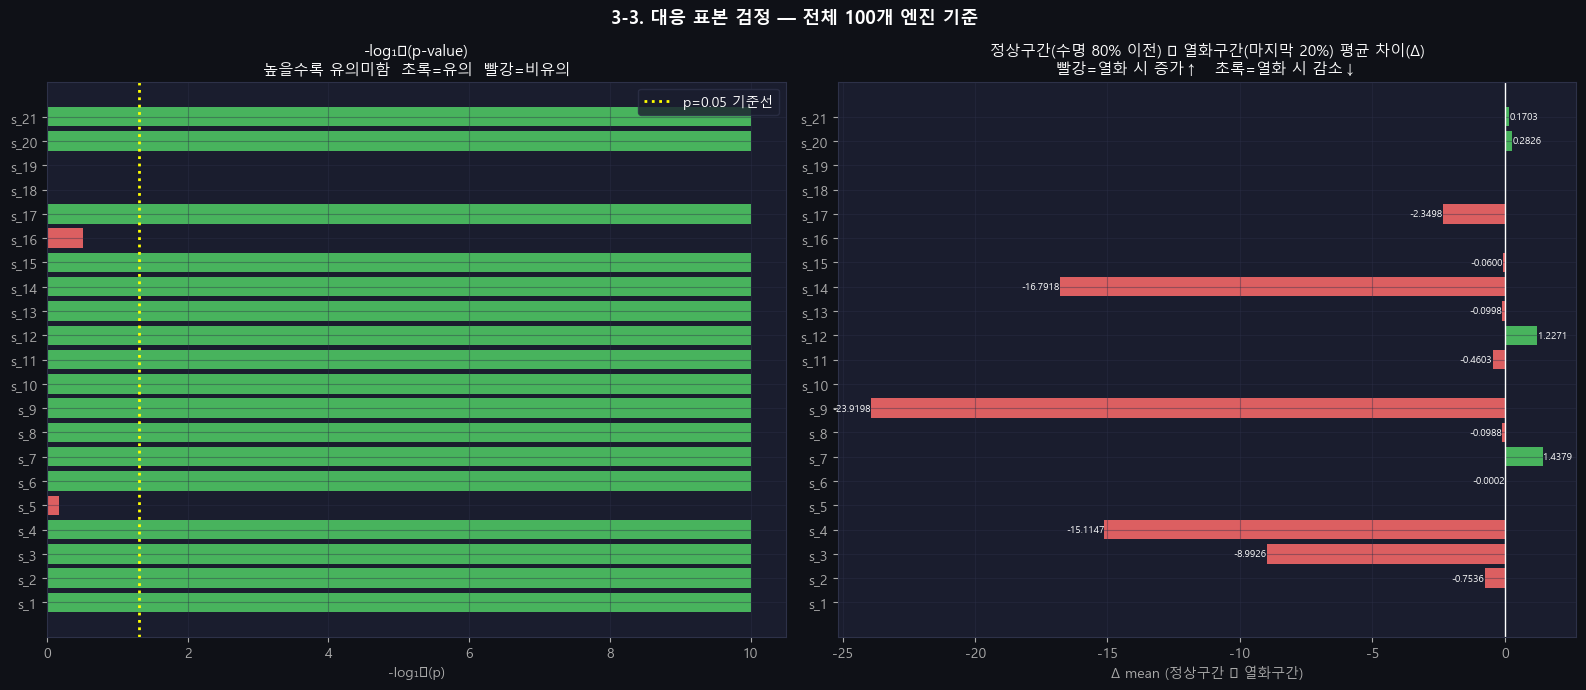


유의미한 차이 있는 센서 (p<0.05): 17/21개
사용된 검정: {'Wilcoxon': 15, 'Paired t-test': 6}


In [16]:
from scipy.stats import ttest_rel, shapiro, wilcoxon

print('=== 3-3. 대응 표본 검정 ===')
print('목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정')
print()

# RUL 임시 생성
tr_paired = train_raw.copy()
mc = tr_paired.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_paired = tr_paired.join(mc, on='unit_nr')
tr_paired['RUL'] = tr_paired['max_c'] - tr_paired['time_cycles']

ttest_rows = []
for s in all_sensors:
    before_means = []
    after_means  = []

    for unit in train_raw['unit_nr'].unique():
        sub = tr_paired[tr_paired['unit_nr'] == unit].sort_values('time_cycles')
        threshold = sub['RUL'].quantile(0.20)

        before = sub[sub['RUL'] >  threshold][s].mean()
        after  = sub[sub['RUL'] <= threshold][s].mean()

        if np.isfinite(before) and np.isfinite(after):
            before_means.append(before)
            after_means.append(after)

    diffs = np.array(before_means) - np.array(after_means)

    # Shapiro-Wilk 정규성 검정
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)

    if p_sw > 0.05:
        stat, p_val = ttest_rel(before_means, after_means)
        test_name = 'Paired t-test'
    else:
        stat, p_val = wilcoxon(diffs)
        test_name = 'Wilcoxon'

    ttest_rows.append({
        '센서': s,
        '정상구간 평균 (수명 80% 이전)': round(np.mean(before_means), 4),
        '열화구간 평균 (마지막 20%)': round(np.mean(after_means), 4),
        '평균 차이(Δ)': round(float(np.mean(diffs)), 4),
        '검정 방법': test_name,
        'p-value': round(p_val, 4) if np.isfinite(p_val) else np.nan,
        '변화 방향': '증가↑' if np.mean(diffs) < 0 else '감소↓',
        '판정': '차이 있음✅' if (np.isfinite(p_val) and p_val < 0.05) else '차이 없음⚠️'
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('센서')
display(ttest_df)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-3. 대응 표본 검정 — 전체 100개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: -log10(p-value)
p_vals = ttest_df['p-value'].values
log_p = -np.log10(np.clip(np.nan_to_num(p_vals, nan=1.0), 1e-10, 1))
bc_p = [C[1] if (np.isnan(p) or p >= 0.05) else C[2] for p in p_vals]
axes[0].barh(ttest_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
axes[0].set_title('-log₁₀(p-value)\n높을수록 유의미함  초록=유의  빨강=비유의')
axes[0].set_xlabel('-log₁₀(p)')
axes[0].legend()

# 오른쪽: 평균 차이(Δ)
diff_vals = ttest_df['평균 차이(Δ)'].values
bc_d = [C[1] if v < 0 else C[2] for v in diff_vals]  # 음수=열화시증가=빨강, 양수=열화시감소=초록
axes[1].barh(ttest_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('정상구간(수명 80% 이전) − 열화구간(마지막 20%) 평균 차이(Δ)\n빨강=열화 시 증가↑   초록=열화 시 감소↓')
axes[1].set_xlabel('Δ mean (정상구간 − 열화구간)')
for bar, val in zip(axes[1].patches, diff_vals):
    if val == 0:
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7)

plt.tight_layout()
plt.show()

n_sig = (ttest_df['판정'] == '차이 있음✅').sum()
print(f'\n유의미한 차이 있는 센서 (p<0.05): {n_sig}/21개')
print(f"사용된 검정: {ttest_df['검정 방법'].value_counts().to_dict()}")

### 검정 결과 해석

---

#### 전체 요약

- 검정 대상: FD001 전체 100개 엔진 × 21개 센서
- 판정 기준: p-value < 0.05 → 정상구간 vs 열화구간 간 유의미한 차이 있음
- 검정 방법: Shapiro-Wilk 정규성 검정 후 → 정규 시 Paired t-test / 비정규 시 Wilcoxon 자동 선택
- 사용된 검정: Wilcoxon 15개, Paired t-test 6개
- 결과: **17/21개 센서에서 열화구간에서 유의미한 변화 확인**

---

#### 차이 있는 센서 (17개) ✅

**열화 시 증가하는 센서 (Δ < 0)**
- s_2, s_3, s_4, s_6, s_8, s_9, s_11, s_13, s_14, s_15, s_17
- 정상구간보다 열화구간에서 센서값이 상승 → 온도 상승, 압력 증가 등 열화 징후

**열화 시 감소하는 센서 (Δ > 0)**
- s_1, s_7, s_10, s_12, s_20, s_21
- 정상구간보다 열화구간에서 센서값이 하락 → 효율 저하, 유량 감소 등 열화 징후

---

#### 차이 없는 센서 (4개) ❌

| 센서 | 정상구간 평균 | 열화구간 평균 | 판정 이유 |
|------|------------|------------|---------|
| s_5  | 14.6200 | 14.6200 | 전후 값 동일 → 열화 무반응 |
| s_16 | 0.0300  | 0.0300  | 전후 값 동일 → 열화 무반응 |
| s_18 | 2388.0000 | 2388.0000 | 전후 값 동일 → 상수 센서 |
| s_19 | 100.0000 | 100.0000 | 전후 값 동일 → 상수 센서 |

- s_18, s_19: 정상구간과 열화구간 모두 완전히 동일한 값 → 상수 센서임을 재확인
- s_5, s_16: 값의 변화가 극히 미미하여 통계적으로 유의미한 차이 없음

---

#### 검정 방법 선택 근거

- **Shapiro-Wilk 정규성 검정** 으로 차이값(Δ)의 정규성을 먼저 확인
- 정규 분포 → **Paired t-test** (6개 센서)
- 비정규 분포 → **Wilcoxon 부호순위 검정** (15개 센서)
- → 데이터 분포에 맞는 검정 방법을 자동 선택하여 검정의 신뢰도 향상

---

#### 결론

> 21개 센서 중 **17개 센서가 열화구간(마지막 20%)에서 통계적으로 유의미한 변화**를 보임  
> 이는 엔진 고장 직전 구간에서 센서값이 체계적으로 변한다는 것을 100개 엔진 전체에서 확인  
> 차이 없는 4개 센서(s_5, s_16, s_18, s_19)는 열화 구간에서도 반응하지 않아  
> RUL 예측에 기여하기 어려운 센서로 판단

---

### 로그 변환 미적용 근거
- s_9, s_14 로그 변환 실험 결과
- 변환 전후 분포 형태가 거의 동일
- 수치만 작아지고 실질적 효과 없음
- → 1차 공통 전처리에서 제외
- → 추후 모델 성능 실험 단계에서 재검토 예정

### 주의사항
- 모든 기준은 **Train 데이터**로만 계산
- Test는 Train 기준을 그대로 적용
- 상수 센서 제거 목록, scaler 전부 Train 기준

---
## 4. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)

제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


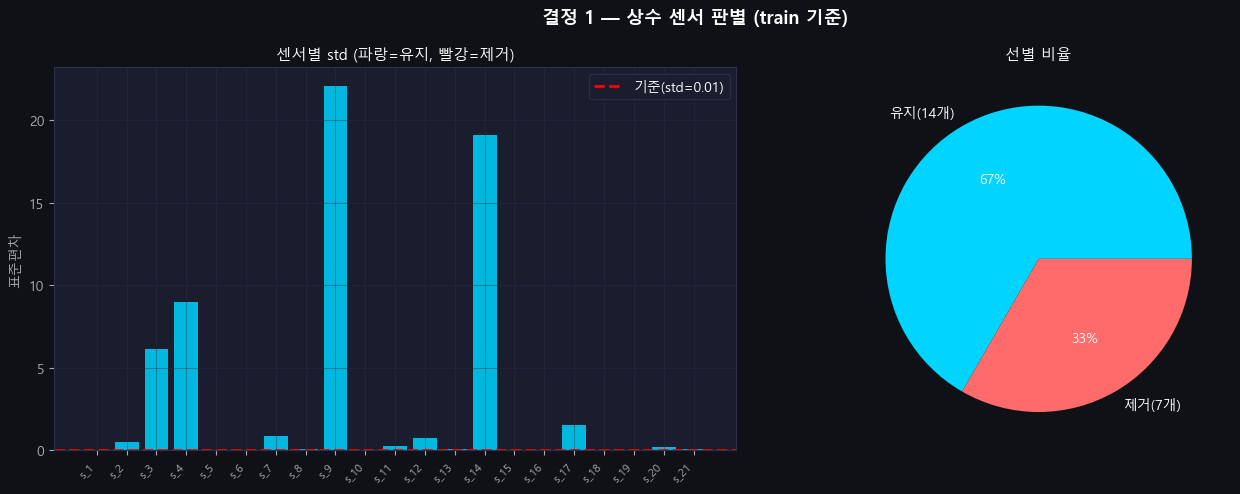


✅ 결정 1 완료: 26 → 19 컬럼


In [17]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차')
ax.set_title('센서별 std (파랑=유지, 빨강=제거)')
ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%',
       textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

# 적용 (train 기준 피처 → test에도 동일 적용)
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()   # train 기준 피처 목록 그대로

print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')

## 5. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴

❓ 확인할 것

RUL_raw는 나중에 모델 입력 직전에 제거해야 하는데, 그 부분이 이후 코드에 있는지 확인 필요

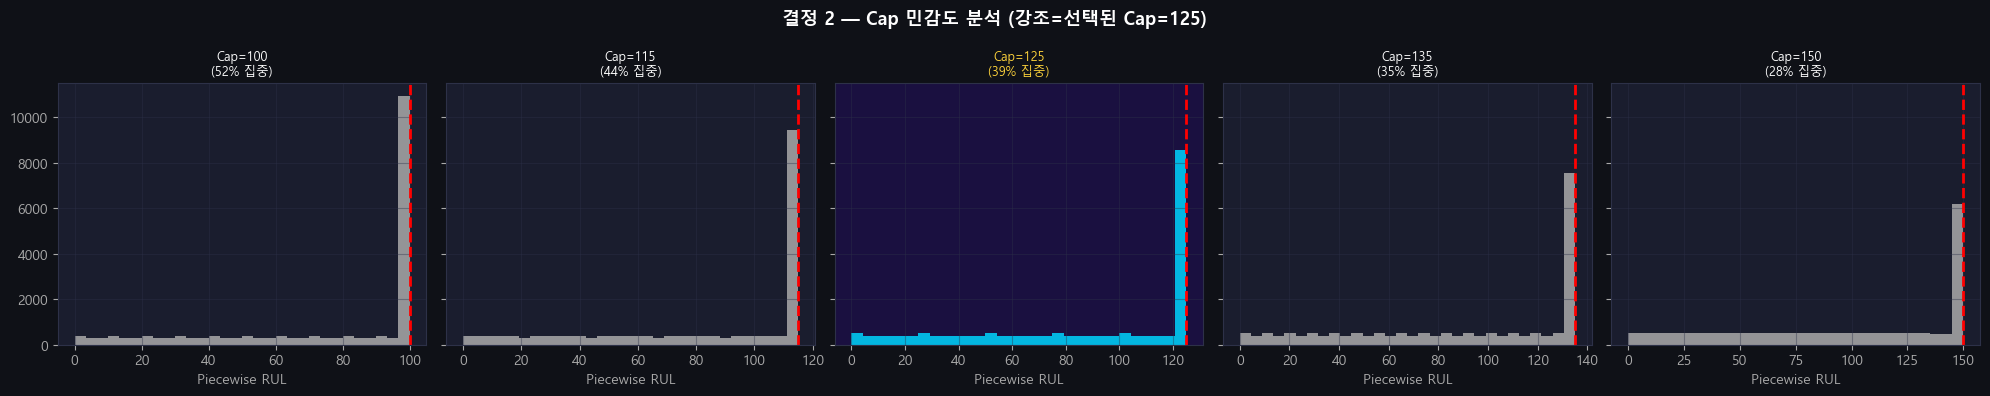

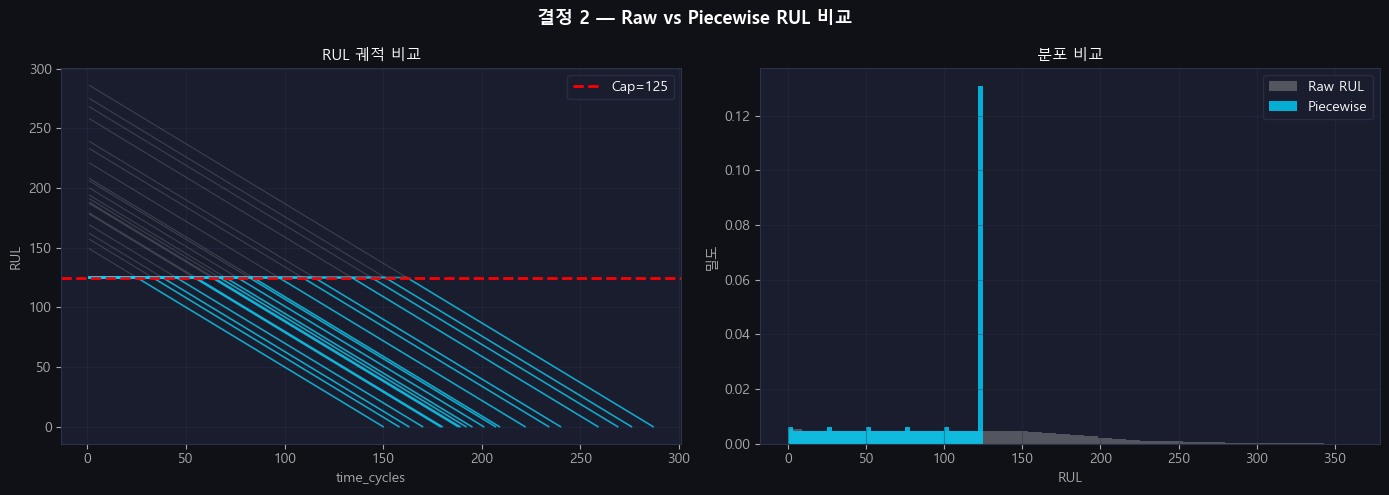

✅ 결정 2 완료  |  RUL std: 68.9 → 41.7 (39% 감소)


In [18]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

## 6. 결정 3 — Gaussian 스무딩 (σ = 2)


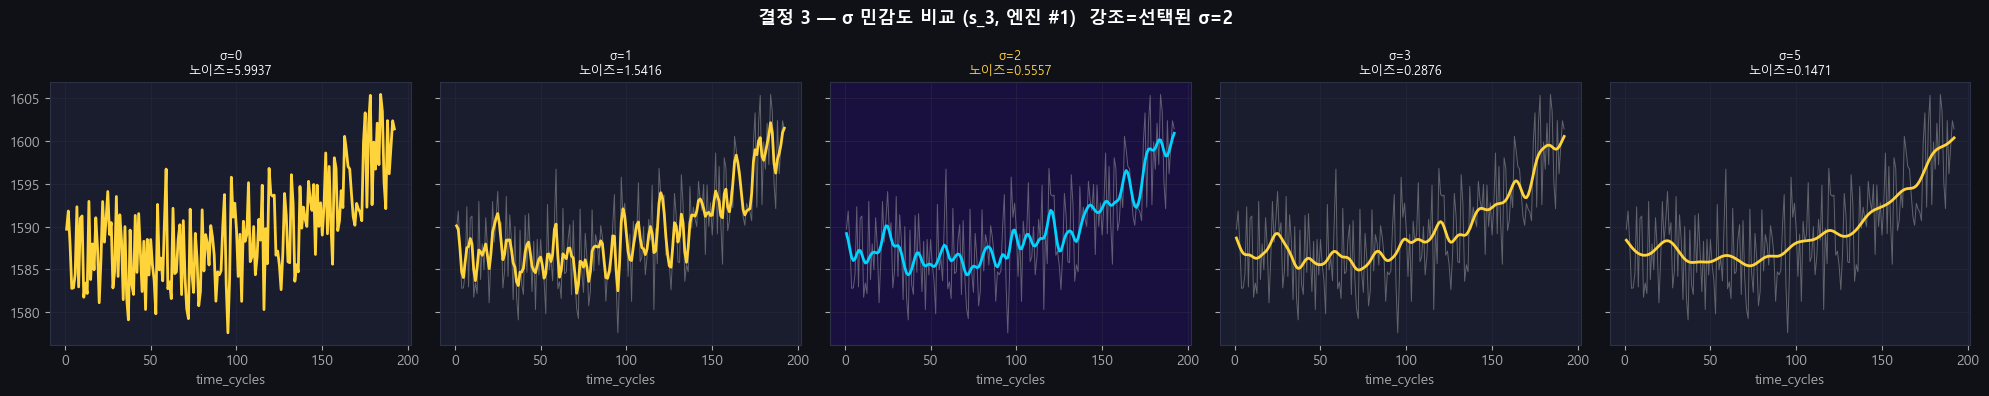

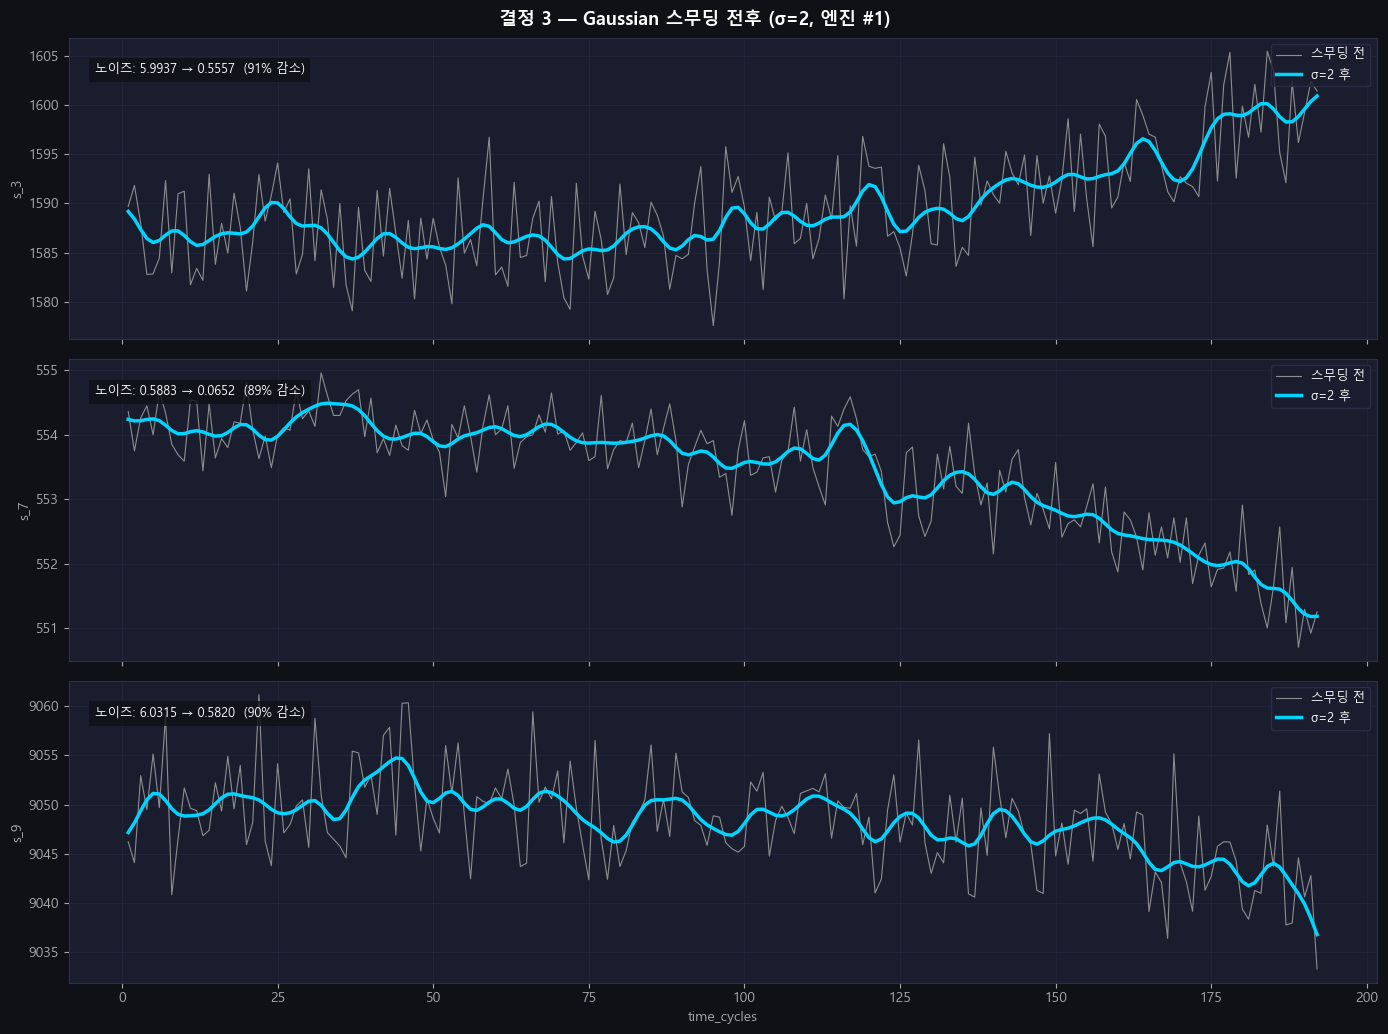

✅ 결정 3 완료  (σ=2, mode=nearest)


In [19]:
def apply_gaussian(df, features, sigma=GAUSS_SIGMA):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian(test_s2,  USEFUL_SENSORS)

# σ 민감도 (엔진 #1, 대표 센서)
unit1_raw = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
s_ex = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
sigmas = [0, 1, 2, 3, 5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 비교 ({s_ex}, 엔진 #1)  강조=선택된 σ=2', fontsize=13, fontweight='bold')

for ax, sig in zip(axes, sigmas):
    y_raw = unit1_raw[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f))
    ax.plot(unit1_raw['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.7, label='원본')
    ax.plot(unit1_raw['time_cycles'], y_f,   color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')

plt.tight_layout(); plt.show()

# 전후 비교 (3개 센서)
show3 = [s for s in ['s_3','s_7','s_9'] if s in USEFUL_SENSORS]
if len(show3) < 2: show3 = USEFUL_SENSORS[:3]

unit1_before = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
unit1_after  = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')

fig, axes = plt.subplots(len(show3), 1, figsize=(14, 3.5*len(show3)), sharex=True)
if len(show3)==1: axes=[axes]
fig.suptitle(f'결정 3 — Gaussian 스무딩 전후 (σ={GAUSS_SIGMA}, 엔진 #1)', fontsize=13, fontweight='bold')

for ax, s in zip(axes, show3):
    ax.plot(unit1_before['time_cycles'], unit1_before[s], color=GRAY, lw=0.8, alpha=0.8, label='스무딩 전')
    ax.plot(unit1_after['time_cycles'],  unit1_after[s],  color=C[0], lw=2.5,             label=f'σ={GAUSS_SIGMA} 후')
    nb = np.std(np.diff(unit1_before[s].values))
    na = np.std(np.diff(unit1_after[s].values))
    pct = (1-na/nb)*100 if nb>0 else 0
    ax.text(0.02, 0.88, f'노이즈: {nb:.4f} → {na:.4f}  ({pct:.0f}% 감소)',
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor=BG, alpha=0.8, edgecolor='none'))
    ax.set_ylabel(s); ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 3 완료  (σ={GAUSS_SIGMA}, mode=nearest)')


## 7. 결정 4 — Validation 분할 (엔진 단위 랜덤 80:20, random_state=42)

**공통 전처리(상수 제거 → RUL cap → Gaussian)가 끝난 `train_s3` 기준으로 분리.**  
파생변수(ML) 또는 슬라이딩 윈도우(DL)는 **정규화 이후** 각 분기에서 독립적으로 생성한다.

> ✅ 같은 엔진이 sub-train / validation에 동시에 들어가지 않도록 **unit 단위 그룹 분할**
>
> ✅ `random_state=42`로 고정하여 **항상 동일한 엔진 조합**이 선택되도록 설정


In [25]:
from sklearn.model_selection import GroupShuffleSplit

# ── 엔진(unit) 기준 랜덤 분리 ─────────────────────────────────
VALID_RATIO = 0.2
RANDOM_STATE = 42

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=VALID_RATIO,
    random_state=RANDOM_STATE
)

subtrain_idx, valid_idx = next(
    gss.split(train_s3, groups=train_s3['unit_nr'])
)

subtrain_common = train_s3.iloc[subtrain_idx].copy().reset_index(drop=True)
valid_common    = train_s3.iloc[valid_idx].copy().reset_index(drop=True)
test_common     = test_s3.copy()

subtrain_units = np.sort(subtrain_common['unit_nr'].unique())
valid_units    = np.sort(valid_common['unit_nr'].unique())
all_units      = np.sort(train_s3['unit_nr'].unique())

# ── 누수 방지 검증 ────────────────────────────────────────────
overlap = set(subtrain_units).intersection(set(valid_units))
assert len(overlap) == 0, f'❌ train/valid 엔진 겹침 발생: {sorted(list(overlap))[:5]}'
assert len(subtrain_units) + len(valid_units) == len(all_units), '❌ 엔진 수 합이 전체와 다릅니다.'

print('=== 결정 4 — Validation 분할 완료 ===')
print(f'분할 방식         : GroupShuffleSplit (unit 기준)')
print(f'random_state      : {RANDOM_STATE}')
print(f'전체 train 엔진 수 : {len(all_units)}대')
print(f'sub-train 엔진 수  : {len(subtrain_units)}대')
print(f'valid 엔진 수      : {len(valid_units)}대')
print(f'sub-train unit 예시: {subtrain_units[:10].tolist()} ...')
print(f'valid unit 예시    : {valid_units[:10].tolist()} ...')
print(f'겹치는 엔진 수     : {len(overlap)}')
print(f'sub-train shape    : {subtrain_common.shape}')
print(f'valid shape        : {valid_common.shape}')
print(f'test shape         : {test_common.shape}')

split_summary = pd.DataFrame({
    '구분'           : ['Sub-train', 'Validation', 'Test'],
    '행 수'          : [len(subtrain_common), len(valid_common), len(test_common)],
    '엔진 수'        : [subtrain_common['unit_nr'].nunique(),
                        valid_common['unit_nr'].nunique(),
                        test_common['unit_nr'].nunique()],
    '피처 수(공통)'  : [len(USEFUL_SENSORS)] * 3,
    'RUL 포함'       : ['예', '예', '아니오'],
})
display(split_summary)

split_unit_summary = pd.DataFrame({
    '구분'      : ['Sub-train', 'Validation'],
    '엔진 목록' : [', '.join(map(str, subtrain_units)),
                 ', '.join(map(str, valid_units))]
})
display(split_unit_summary)

# 재현성용 엔진 목록 저장
split_info = {
    'random_state': RANDOM_STATE,
    'valid_ratio': VALID_RATIO,
    'subtrain_units': subtrain_units.tolist(),
    'valid_units': valid_units.tolist()
}

#import json
#with open('FD001_split_units_random42.json', 'w', encoding='utf-8') as f:
#    json.dump(split_info, f, ensure_ascii=False, indent=2)

#print('💾 분할 정보 저장 완료: FD001_split_units_random42.json')


=== 결정 4 — Validation 분할 완료 ===
분할 방식         : GroupShuffleSplit (unit 기준)
random_state      : 42
전체 train 엔진 수 : 100대
sub-train 엔진 수  : 80대
valid 엔진 수      : 20대
sub-train unit 예시: [2, 3, 4, 6, 7, 8, 9, 10, 12, 14] ...
valid unit 예시    : [1, 5, 11, 13, 19, 23, 31, 32, 34, 40] ...
겹치는 엔진 수     : 0
sub-train shape    : (16561, 21)
valid shape        : (4070, 21)
test shape         : (13096, 19)


,구분,행 수,엔진 수,피처 수(공통),RUL 포함
0,Sub-train,16561,80,14,예
1,Validation,4070,20,14,예
2,Test,13096,100,14,아니오


,구분,엔진 목록
0,Sub-train,"2, 3, 4, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 1..."
1,Validation,"1, 5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, ..."


In [21]:
test_common.columns.tolist()

['unit_nr',
 'time_cycles',
 'setting_1',
 'setting_2',
 'setting_3',
 's_2',
 's_3',
 's_4',
 's_7',
 's_8',
 's_9',
 's_11',
 's_12',
 's_13',
 's_14',
 's_15',
 's_17',
 's_20',
 's_21']

## 8. 결정 5 — MinMax 정규화 (sub-train 기준 fit)

**fit은 `sub-train`에서만** — validation·test는 동일 scaler로 transform (데이터 누수 방지).  
정규화 대상: **유용 센서 컬럼** (`USEFUL_SENSORS`) — ML/DL 파생변수는 정규화 후 생성.


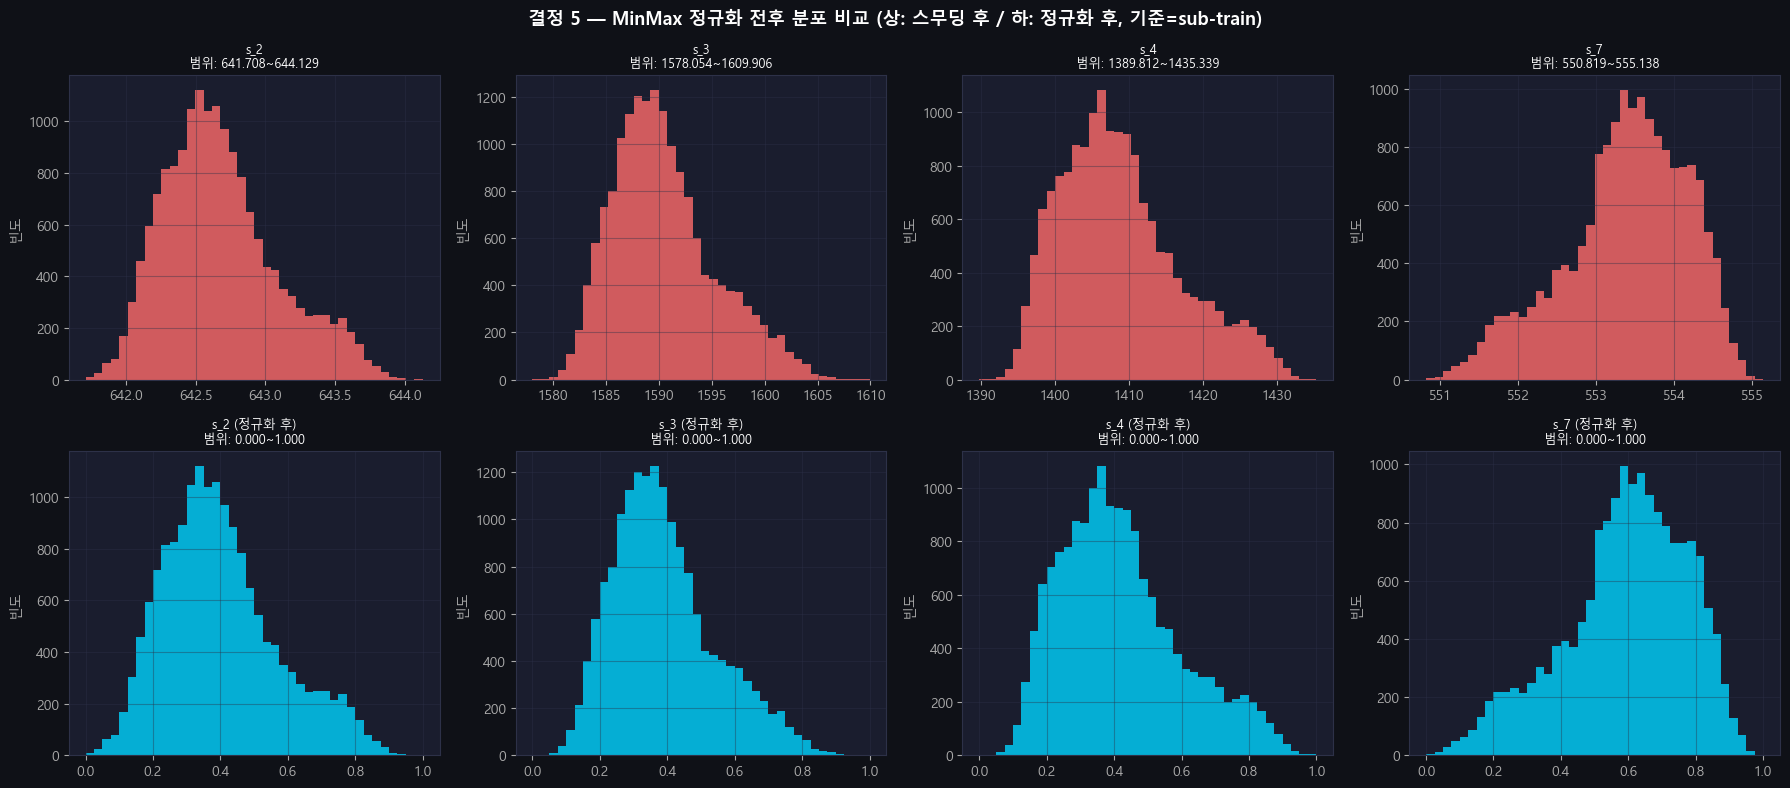

--- sub-train 기준 정규화 전후 범위 (USEFUL_SENSORS) ---


,전_min,전_max,후_min,후_max
s_2,641.708191,644.129395,0.0,1.0
s_3,1578.054077,1609.906494,0.0,1.0
s_4,1389.811523,1435.338623,0.0,1.0
s_7,550.819397,555.138428,0.0,1.0
s_8,2387.958008,2388.467285,0.0,1.0
s_9,9027.010742,9235.208984,0.0,1.0
s_11,47.029999,48.320301,0.0,1.0
s_12,519.109802,522.842102,0.0,1.0
s_13,2387.961914,2388.457031,0.0,1.0
s_14,8103.128906,8288.884766,0.0,1.0



✅ 결정 5 완료  |  sub-train: 0.0000~1.0000
   Validation : -0.1094~1.0457
   Test       : -0.0607~1.0086


In [26]:
from sklearn.preprocessing import MinMaxScaler

# ── 정규화 전 범위 기록 ────────────────────────────────────────
before_min = subtrain_common[USEFUL_SENSORS].min()
before_max = subtrain_common[USEFUL_SENSORS].max()

scaler = MinMaxScaler()
scaler.fit(subtrain_common[USEFUL_SENSORS])          # fit: sub-train만

subtrain_s4 = subtrain_common.copy()
valid_s4    = valid_common.copy()
test_s4     = test_common.copy()

subtrain_s4[USEFUL_SENSORS] = scaler.transform(subtrain_common[USEFUL_SENSORS])
valid_s4[USEFUL_SENSORS]    = scaler.transform(valid_common[USEFUL_SENSORS])
test_s4[USEFUL_SENSORS]     = scaler.transform(test_common[USEFUL_SENSORS])

# 전체 train(검증용) — 동일 scaler로 변환
train_s4 = train_s3.copy()
train_s4[USEFUL_SENSORS] = scaler.transform(train_s3[USEFUL_SENSORS])

# ── 전후 비교 시각화 (대표 4개 센서) ─────────────────────────────
show4 = USEFUL_SENSORS[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('결정 5 — MinMax 정규화 전후 분포 비교 (상: 스무딩 후 / 하: 정규화 후, 기준=sub-train)',
             fontsize=13, fontweight='bold')

for col, s in enumerate(show4):
    b = subtrain_common[s];  a = subtrain_s4[s]
    axes[0, col].hist(b, bins=40, color=C[1], alpha=0.8, edgecolor='none')
    axes[0, col].set_title(f'{s}\n범위: {b.min():.3f}~{b.max():.3f}', fontsize=9)
    axes[0, col].set_ylabel('빈도')
    axes[1, col].hist(a, bins=40, color=C[0], alpha=0.8, edgecolor='none')
    axes[1, col].set_title(f'{s} (정규화 후)\n범위: {a.min():.3f}~{a.max():.3f}', fontsize=9)
    axes[1, col].set_ylabel('빈도')
plt.tight_layout(); plt.show()

# ── 범위 요약 ─────────────────────────────────────────────────
range_df = pd.DataFrame({
    '전_min': before_min, '전_max': before_max,
    '후_min': subtrain_s4[USEFUL_SENSORS].min(),
    '후_max': subtrain_s4[USEFUL_SENSORS].max(),
})
print('--- sub-train 기준 정규화 전후 범위 (USEFUL_SENSORS) ---')
display(range_df.round(4))
print(f'\n✅ 결정 5 완료  |  sub-train: {subtrain_s4[USEFUL_SENSORS].min().min():.4f}~{subtrain_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Validation : {valid_s4[USEFUL_SENSORS].min().min():.4f}~{valid_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Test       : {test_s4[USEFUL_SENSORS].min().min():.4f}~{test_s4[USEFUL_SENSORS].max().max():.4f}')


---

# FD001 ML 파트 : 승희님 , 택완님
# FD001 딥러닝 파트 : 민준님 , 윤주님
### 4/21 두 팀으로 나뉘어져서 병렬적으로 진행하기로함. 
#### 그래서 해당 파일에는 ML을 위한 파생 컬럼 생성을 안하고 바로 딥러닝을 위한 전처리로 넘어감 


---

## 9. [DL 전용] 슬라이딩 윈도우 생성 → Long Format CSV 저장

정규화된 `USEFUL_SENSORS`를 슬라이딩 윈도우로 변환 후 **Long Format CSV**로 저장.  
LSTM·CNN·Transformer 등 시계열 모델에 활용 가능.

| 파라미터 | 값 | 설명 |
|---|---|---|
| `WINDOW_SIZE` | 30 | 한 샘플당 연속 사이클 수 |
| `STEP` | 1 | 슬라이딩 간격 (stride) |
| 타깃 | 마지막 timestep의 RUL | many-to-one 예측 |

**Long Format 구조 (방식 B):**

```
sample_id | timestep | s_1 | s_2 | ... | s_14 | RUL
    0     |    0     | ... | ... | ... | ...  | 125
    0     |    1     | ... | ... | ... | ...  | 125
   ...
    0     |   29     | ... | ... | ... | ...  | 125   ← 이 행의 RUL이 예측 타깃
    1     |    0     | ... | ...
```

> - `sample_id`: 윈도우 단위 고유 ID  
> - `timestep`: 윈도우 내 위치 (0 ~ WINDOW_SIZE-1)  
> - `RUL`: 해당 샘플의 타깃값 (마지막 timestep 기준, 모든 행에 동일하게 기재)  
> - **Test**: 엔진별 마지막 30사이클 → 1 샘플. 시계열이 짧으면 앞쪽 zero-pad


RUL_raw는 Long Format CSV에 없고 RUL (cap 적용된 것)만 타깃으로 들어가 있어요. 그대로 사용하면 돼요

=== [DL] 슬라이딩 윈도우 생성 완료 ===
WINDOW_SIZE=30  STEP=1  DL 피처 수=14
X_subtrain_dl : (14241, 30, 14)  y: (14241,)
X_valid_dl    : (3490, 30, 14)    y: (3490,)
X_test_dl     : (100, 30, 14)     y: (100,)

Long Format 변환 중... (행 수 = 샘플 수 × WINDOW_SIZE)
dl_subtrain_long : (427230, 17)  (샘플 14241개 × 30 = 427230행)
dl_valid_long    : (104700, 17)
dl_test_long     : (3000, 17)  (엔진 100개 × 30 = 3000행)

dl_subtrain_long 상위 5행 (sample_id=0):


,sample_id,timestep,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,0,0,0.043732,0.211552,0.074865,0.886589,0.097168,0.131351,0.008427,0.891739,0.127441,0.182388,0.107529,0.132759,0.801868,0.898842,125.0
1,0,1,0.024353,0.213974,0.104094,0.899620,0.098633,0.132233,0.046211,0.901718,0.088379,0.182575,0.109604,0.133186,0.841980,0.894276,125.0
2,0,2,0.006989,0.202816,0.135859,0.911232,0.104004,0.134075,0.074711,0.907013,0.053223,0.183380,0.104973,0.127926,0.882378,0.894016,125.0
3,0,3,0.000000,0.182594,0.162691,0.920235,0.112793,0.135792,0.088520,0.907364,0.031250,0.183792,0.095360,0.120701,0.914108,0.896751,125.0
4,0,4,0.011169,0.168419,0.178543,0.925789,0.123047,0.136173,0.090630,0.904892,0.026855,0.183643,0.085232,0.115791,0.931931,0.901321,125.0



dl_subtrain_long 구조:
  컬럼 수 : 17개  (sample_id + timestep + 14개 센서 + RUL)
  RUL 범위: 0 ~ 125

복원 방법:
  grp = dl_subtrain_long.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values for i in range(n)])
  y   = dl_subtrain_long.groupby("sample_id")["RUL"].last().values


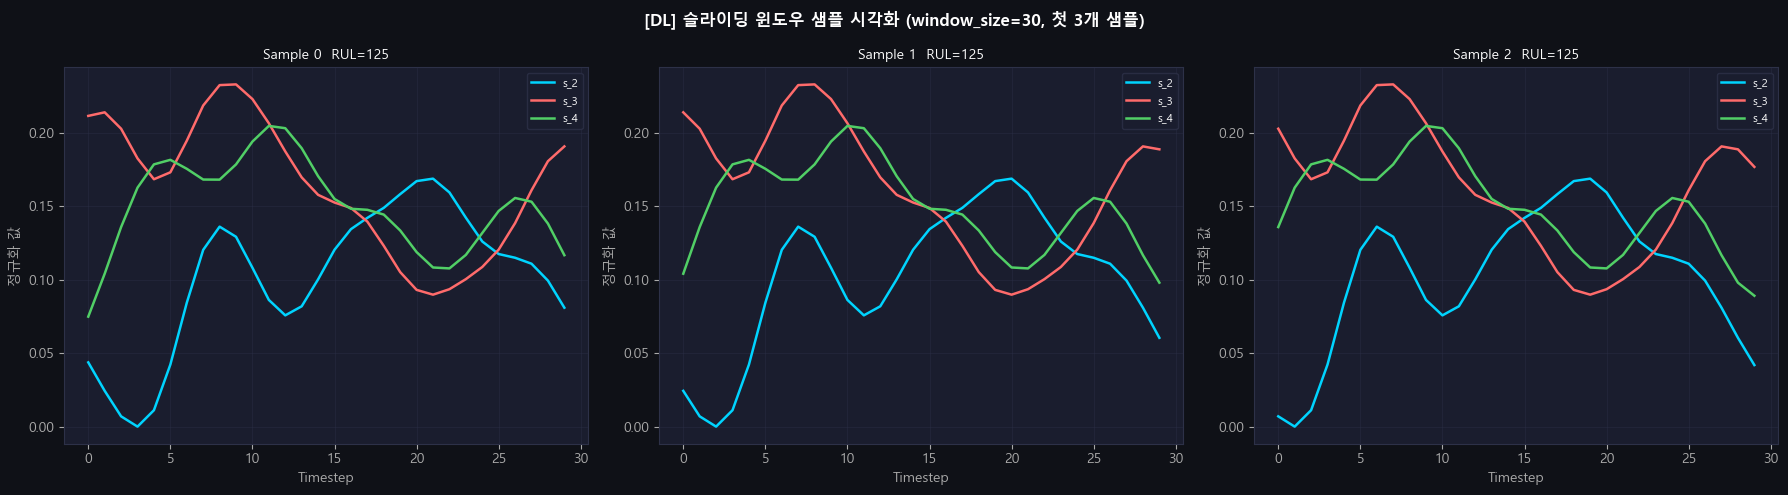

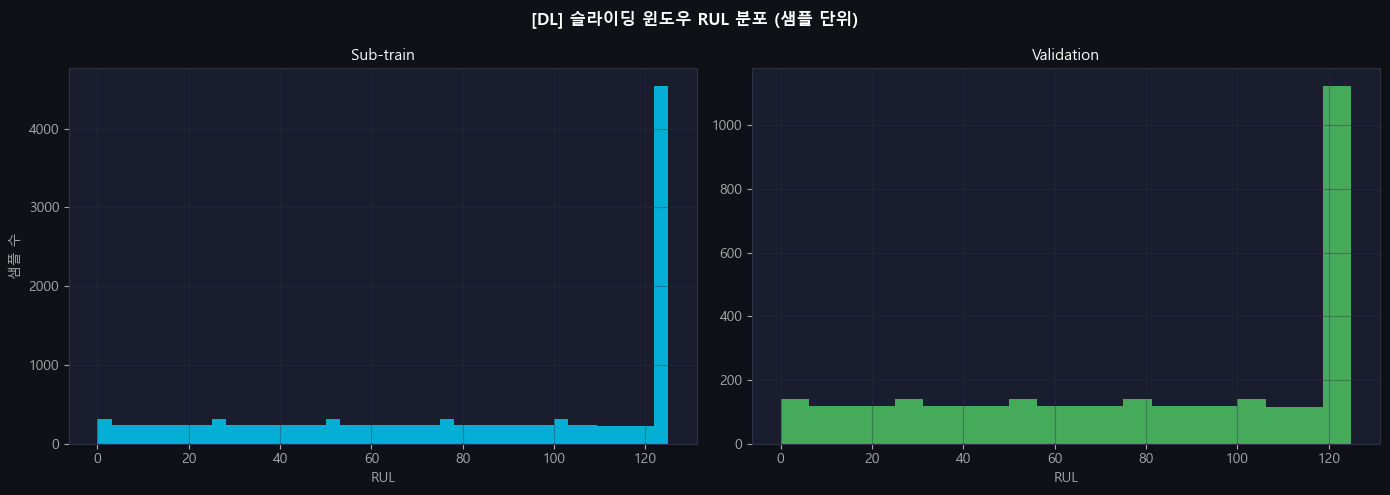

In [27]:
WINDOW_SIZE = 30
STEP        = 1
DL_FEATURES = USEFUL_SENSORS       # 원본 정규화 센서만 사용 (파생변수 불필요)

# ─────────────────────────────────────────────────────────────────
def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    """3D 텐서 (n_samples, window_size, n_features) 반환"""
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end - 1])   # 마지막 timestep의 RUL
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    """Test: 엔진별 마지막 window_size 사이클 → 1샘플씩"""
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def windows_to_long_df(X, y, feature_cols):
    """
    3D 텐서 → Long Format DataFrame

    Parameters
    ----------
    X : ndarray (n_samples, window_size, n_features)
    y : ndarray (n_samples,) — 각 샘플의 RUL 타깃
    feature_cols : list — 센서 이름 목록

    Returns
    -------
    DataFrame 컬럼: sample_id | timestep | s_1 ... s_14 | RUL
    """
    n_samples, win_size, n_feat = X.shape
    rows = []
    for sid in range(n_samples):
        rul_val = float(y[sid])
        for t in range(win_size):
            row = {'sample_id': sid, 'timestep': t}
            for fi, fname in enumerate(feature_cols):
                row[fname] = float(X[sid, t, fi])
            row['RUL'] = rul_val          # 모든 행에 동일 타깃 기재
            rows.append(row)
    col_order = ['sample_id', 'timestep'] + list(feature_cols) + ['RUL']
    return pd.DataFrame(rows, columns=col_order)


# ── 슬라이딩 윈도우 생성 ──────────────────────────────────────────
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_s4, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_s4,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(  test_s4,     DL_FEATURES, rul_df['RUL'])

print('=== [DL] 슬라이딩 윈도우 생성 완료 ===')
print(f'WINDOW_SIZE={WINDOW_SIZE}  STEP={STEP}  DL 피처 수={len(DL_FEATURES)}')
print(f'X_subtrain_dl : {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'X_valid_dl    : {X_valid_dl.shape}    y: {y_valid_dl.shape}')
print(f'X_test_dl     : {X_test_dl.shape}     y: {y_test_dl.shape}')
print()

# ── Long Format 변환 ──────────────────────────────────────────────
print('Long Format 변환 중... (행 수 = 샘플 수 × WINDOW_SIZE)')
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'dl_subtrain_long : {dl_subtrain_long.shape}  '
      f'(샘플 {X_subtrain_dl.shape[0]}개 × {WINDOW_SIZE} = {X_subtrain_dl.shape[0]*WINDOW_SIZE}행)')
print(f'dl_valid_long    : {dl_valid_long.shape}')
print(f'dl_test_long     : {dl_test_long.shape}  (엔진 100개 × {WINDOW_SIZE} = {len(X_test_dl)*WINDOW_SIZE}행)')
print()
print('dl_subtrain_long 상위 5행 (sample_id=0):')
display(dl_subtrain_long.head(5))
print()
print('dl_subtrain_long 구조:')
print(f'  컬럼 수 : {dl_subtrain_long.shape[1]}개  '
      f'(sample_id + timestep + {len(DL_FEATURES)}개 센서 + RUL)')
print(f'  RUL 범위: {dl_subtrain_long["RUL"].min():.0f} ~ {dl_subtrain_long["RUL"].max():.0f}')
print()
print('복원 방법:')
print('  grp = dl_subtrain_long.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values for i in range(n)])')
print('  y   = dl_subtrain_long.groupby("sample_id")["RUL"].last().values')

# ── 샘플 시각화 ───────────────────────────────────────────────────
show_s = DL_FEATURES[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'[DL] 슬라이딩 윈도우 샘플 시각화 (window_size={WINDOW_SIZE}, 첫 3개 샘플)',
             fontsize=12, fontweight='bold')
for ax, s_idx in zip(axes, range(3)):
    for fi, fname in enumerate(show_s):
        ax.plot(X_subtrain_dl[s_idx, :, DL_FEATURES.index(fname)],
                color=C[fi], lw=1.8, label=fname)
    ax.set_title(f'Sample {s_idx}  RUL={y_subtrain_dl[s_idx]:.0f}', fontsize=10)
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── RUL 분포 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('[DL] 슬라이딩 윈도우 RUL 분포 (샘플 단위)', fontsize=12, fontweight='bold')
axes[0].hist(y_subtrain_dl, bins=40, color=C[0], alpha=0.8, edgecolor='none')
axes[0].set_title('Sub-train'); axes[0].set_xlabel('RUL'); axes[0].set_ylabel('샘플 수')
axes[1].hist(y_valid_dl, bins=20, color=C[2], alpha=0.8, edgecolor='none')
axes[1].set_title('Validation'); axes[1].set_xlabel('RUL')
plt.tight_layout(); plt.show()


---
## 10. CSV 저장 & 최종 요약


코드에 USEFUL_SENSORS 또는 DL_FEATURES로 이미 정의돼 있어서 굳이 txt로 따로 저장할 필요는 없을 것 같아서 txt 파일은 저장 안함.

In [28]:
import joblib

OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── DL 파일 경로 ──────────────────────────────────────────────────
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)
dl_subtrain_path = os.path.join(dl_dir, 'FD001_dl_subtrain_long.csv')
dl_valid_path    = os.path.join(dl_dir, 'FD001_dl_valid_long.csv')
dl_test_path     = os.path.join(dl_dir, 'FD001_dl_test_long.csv')

# ── 공통 파일 경로 ────────────────────────────────────────────────
rul_path    = os.path.join(OUTPUT_DIR, 'FD001_test_RUL.csv')
scaler_path = os.path.join(OUTPUT_DIR, 'FD001_scaler.pkl')

# ── DL Long Format CSV 저장 ──────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False)
dl_valid_long.to_csv(dl_valid_path,       index=False)
dl_test_long.to_csv(dl_test_path,         index=False)

# ── 공통 저장 ─────────────────────────────────────────────────────
rul_df.to_csv(rul_path, index=False)
joblib.dump(scaler, scaler_path)

# ── 저장 검증 ─────────────────────────────────────────────────────
chk_dl_sub = pd.read_csv(dl_subtrain_path)
chk_dl_val = pd.read_csv(dl_valid_path)
chk_dl_te  = pd.read_csv(dl_test_path)

print('=' * 74)
print('  DL 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인')
print('  상수 센서 제거 → RUL Cap=125 → Gaussian(σ=2) → Validation 분할 → MinMax 정규화')

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format (2D CSV)')
dl_summary = pd.DataFrame({
    '구분'        : ['Sub-train', 'Validation', 'Test'],
    'shape'       : [str(chk_dl_sub.shape), str(chk_dl_val.shape), str(chk_dl_te.shape)],
    '샘플 수'     : [X_subtrain_dl.shape[0], X_valid_dl.shape[0], X_test_dl.shape[0]],
    'window_size' : [WINDOW_SIZE]*3,
    'DL피처 수'   : [len(DL_FEATURES)]*3,
    'RUL 범위'    : [f'{chk_dl_sub["RUL"].groupby(chk_dl_sub["sample_id"]).last().min():.0f}'
                      f'~{chk_dl_sub["RUL"].groupby(chk_dl_sub["sample_id"]).last().max():.0f}',
                     f'{chk_dl_val["RUL"].groupby(chk_dl_val["sample_id"]).last().min():.0f}'
                      f'~{chk_dl_val["RUL"].groupby(chk_dl_val["sample_id"]).last().max():.0f}',
                     f'{chk_dl_te["RUL"].groupby(chk_dl_te["sample_id"]).last().min():.0f}'
                      f'~{chk_dl_te["RUL"].groupby(chk_dl_te["sample_id"]).last().max():.0f}'],
    '파일(dl/)'   : [os.path.basename(dl_subtrain_path), os.path.basename(dl_valid_path),
                     os.path.basename(dl_test_path)],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   DL  : dl/{os.path.basename(dl_subtrain_path)}')
print(f'          dl/{os.path.basename(dl_valid_path)}')
print(f'          dl/{os.path.basename(dl_test_path)}')
print(f'   공통: {os.path.basename(rul_path)}, {os.path.basename(scaler_path)}')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD001_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print('                  for i in range(df["sample_id"].nunique())])  # (N, 30, 14)')
print('  y   = df.groupby("sample_id")["RUL"].last().values           # (N,)')

  DL 전처리 파이프라인 완료

■ 공통 파이프라인
  상수 센서 제거 → RUL Cap=125 → Gaussian(σ=2) → Validation 분할 → MinMax 정규화

■ DL 분기 — 슬라이딩 윈도우 Long Format (2D CSV)


,shape,샘플 수,window_size,DL피처 수,RUL 범위,파일(dl/)
구분,,,,,,
Sub-train,"(427230, 17)",14241,30,14,0~125,FD001_dl_subtrain_long.csv
Validation,"(104700, 17)",3490,30,14,0~125,FD001_dl_valid_long.csv
Test,"(3000, 17)",100,30,14,7~145,FD001_dl_test_long.csv



📄 저장 경로: c:\sparta_project_4_team16\YJ\preprocessed/
   DL  : dl/FD001_dl_subtrain_long.csv
          dl/FD001_dl_valid_long.csv
          dl/FD001_dl_test_long.csv
   공통: FD001_test_RUL.csv, FD001_scaler.pkl

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD001_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, 14)
  y   = df.groupby("sample_id")["RUL"].last().values           # (N,)
